In [47]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from matplotlib.lines import Line2D

In [2]:
base = r"D:\JHAhn\files"

In [3]:
# df = pd.read_excel(os.path.join(base, "안재혁_8641_Auto_ALPS_index_19-24_main+CTI.xlsx"))
df = pd.read_excel(os.path.join(base, "1120_8641_ALPS+TiV_UPDATED.xlsx"))
df["PID"] = df["PID"].astype(str).str.zfill(8)
df = df.set_index("PID")
df

,PDI,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,...,LT_CTI_Assoc_Dyy,LT_CTI_Assoc_Dzz,LT_CTI-ALPS index,RT_CTI_Proj_Dxx,RT_CTI_Proj_Dyy,RT_CTI_Proj_Dzz,RT_CTI_Assoc_Dxx,RT_CTI_Assoc_Dyy,RT_CTI_Assoc_Dzz,RT_CTI-ALPS index
PID,,,,,,,,,,,,,,,,,,,,,
00310282,EPT2022AD01_KDKM_NODDI32,AD,2,66,1,F,NaN,23,0.5,0.698943,...,0.164354,0.097310,1.478380,0.054003,0.054375,0.240860,0.184253,0.287577,0.178141,1.024686
00454439,EPT2022AD02_SKM_NODDI32,AD,2,74,0,M,NaN,13,2.0,0.908146,...,0.662543,0.608131,1.031772,0.571705,0.575767,0.810732,0.635722,0.745992,0.640786,0.992498
00461257,EPT2022AD03_KKS_NODDI32,SaMCI,1,74,1,F,12.0,27,0.5,0.675541,...,0.218842,0.130708,1.237209,0.162839,0.164997,0.514460,0.213250,0.368805,0.217572,0.983061
00612238,EPT2022AD05_KIJD_NODDI32,AD,2,83,1,F,NaN,24,1.0,0.689047,...,0.302673,0.241407,1.154961,0.320157,0.311376,0.667341,0.353844,0.461456,0.331211,1.048886
00710431,EPT2022AD063_BPB_NODDI32,SaMCI,1,74,1,F,6.0,26,0.5,0.738484,...,0.279020,0.148243,1.073432,0.070293,0.067808,0.255883,0.215472,0.385115,0.222588,0.984049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
04058635,MREPT2020AD18_YHS_NODDI32,AD,2,86,1,F,1.0,14,1.0,0.615685,...,0.432221,0.282059,1.092207,0.198349,0.185045,0.486609,0.217757,0.325501,0.195334,1.093927
08700631,MREPT2020AD24_YYS_NODDI32,AD,2,60,1,F,6.0,25,1.0,0.537840,...,0.371340,0.217176,1.203538,0.093545,0.113938,0.350324,0.220411,0.385111,0.261687,0.835825
05533209,MREPT2020AD28_YYL_NODDI32,AD,2,80,1,F,NaN,13,1.0,0.818946,...,0.585913,0.396878,1.075353,0.263975,0.261592,0.578273,0.334748,0.527785,0.340203,0.994895


In [4]:
for column in df.columns:
    print(f"Col name: {column}")
    print(f"Data type: {df[column].dtype}")
    print("Unique values:")
    print(df[column].unique())
    print("-"*50)

Col name: PDI
Data type: object
Unique values:
['EPT2022AD01_KDKM_NODDI32' 'EPT2022AD02_SKM_NODDI32'
 'EPT2022AD03_KKS_NODDI32' 'EPT2022AD05_KIJD_NODDI32'
 'EPT2022AD063_BPB_NODDI32' 'EPT2022AD065_CGS_NODDI32'
 'EPT2022AD069_LBD_NODDI32' 'EPT2022AD07_YMY_NODDI32'
 'EPT2022AD070_KSH_NODDI32' 'EPT2022AD10_HSY_NODDI32'
 'EPT2022AD11_PSI_NODDI32' 'EPT2022AD12_SYS_NODDI32'
 'EPT2022AD17_KHS_NODDI32' 'EPT2022AD18_PKW_NODDI32'
 'EPT2022AD19_YJH_NODDI32' 'EPT2022AD20_KYS_NODDI32'
 'EPT2022AD21_KOJ_NODDI32' 'EPT2022AD23_SKSH_NODDI32'
 'EPT2022AD27_KDS_NODDI32' 'EPT2022AD29_LKH_NODDI32'
 'EPT2022AD30_NNO_NODDI32' 'EPT2022AD31_HSB_NODDI32'
 'EPT2022AD34_KMB_NODDI32' 'EPT2022AD38_YYS_NODDI32'
 'EPT2022AD39_LJS_NODDI32' 'EPT2022AD40_RKJ_NODDI32'
 'EPT2022AD41_SIJ_NODDI32' 'EPT2022AD42_HPB_NODDI32'
 'EPT2022AD43_CDH_NODDI32' 'EPT2022AD44_LKJ_NODDI32'
 'EPT2022AD45_CHS_NODDI32' 'EPT2022AD49_PCS_NODDI32'
 'EPT2022AD50_YYH_NODDI32' 'EPT2022AD067_JSO_NODDI32'
 'EPT2023AD01_KMH_NODDI32' 'EPT2023AD04_KJU_

In [5]:
## Mapping columns
row_to_alps_col = {
    ("ALL", "LT"): "LT_ALL_ALPS index",
    ("ALL", "RT"): "RT_ALL_ALPS index",
    ("b800", "LT"): "LT_b800_ALPS index",
    ("b800", "RT"): "RT_b800_ALPS index",
    ("b2000", "LT"): "LT_b2000_ALPS index",
    ("b2000", "RT"): "RT_b2000_ALPS index",
    ("CTI", "LT"): "LT_CTI-ALPS index",
    ("CTI", "RT"): "RT_CTI-ALPS index"
}

rows = [
    ("ALL", "DTI-ALPS (ALL)"),
    ("b800", "DTI-ALPS (b=800)"),
    ("b2000", "DTI-ALPS (b=2000)"),
    ("CTI", "CTI-ALPS (ALL)")
]
sides = [("LT", "Left"), ("RT", "Right")]

# region & component
regions = ["Hippocampus"]    # , "Insula"
comps = ["HFC", "EC", "IC"]

# Column naming : Component by 'Side' & 'Regions'
def comp_cols(side, region):
    # 예: side='LT', region='Hippocampus' → ['HFC_LT_Hippocampus', 'EC_LT_Hippocampus', 'IC_LT_Hippocampus']
    return [f"{c}_{side}_{region}" for c in comps]

# y-Axis: column 'Group' --> 0, 1, 2
group_levels = [0, 1, 2]
group_labels = {0: "CN", 1: "MCI", 2: "AD"}

In [6]:
# Plotting
def plot_region_figure(df, region, figsize=(10, 12), dpi=120):
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=figsize, dpi=dpi, sharex=True, sharey=False)
    fig.suptitle(f"{region}: ALPS indices (HFC/EC/IC overlay)", fontsize=16, y=0.985)

    # x-axis setting (이제 Group이 x축)
    for ax in axes.ravel():
        ax.set_xticks(group_levels)
        ax.set_xticklabels([group_labels[g] for g in group_levels])

    # Each cells: (row: band, col: side)
    for r, (band, row_title) in enumerate(rows):
        for c, (side, side_title) in enumerate(sides):
            ax = axes[r, c]
            ax.set_title(f"{side_title} • {row_title}", fontsize=11)

            # ALPS index cols for y-axis
            alps_col = row_to_alps_col[(band, side)]
            if alps_col not in df.columns:
                ax.text(0.5, 0.5, f"Missing ALPS:\n{alps_col}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, alpha=0.7)
                continue

            # mean(ALPS index) by groups
            y_by_group = df.groupby("Group")[alps_col].mean().reindex(group_levels)

            # Same side components: 3-Conductivity cols (HFC/EC/IC)
            cols = comp_cols(side, region)
            missing = [col for col in cols if col not in df.columns]
            if missing:
                ax.text(0.5, 0.5, "Missing comps:\n" + "\n".join(missing), ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, alpha=0.7)

            # 3 Lines for each subplot
            offsets = [-0.06, 0.0, 0.06]  # comp별 시각적 분리 (x축 스텝 내에서 약간만)
            for i, comp in enumerate(comps):
                col = f"{comp}_{side}_{region}"
                if col not in df.columns:
                    continue

                # x: Group(0,1,2) + offset / y: mean(ALPS index) by group
                x_vals = np.array(group_levels, dtype=float) + offsets[i]
                y_vals = y_by_group.values.astype(float)

                ax.plot(x_vals, y_vals, marker="o", label=comp)

            ax.set_xlabel("Group")
            ax.set_ylabel(f"{alps_col}")

            # per-subplot legend 제거 (figure-level로 통합)
            # if r == 0 and c == 1:
            #     ax.legend(title="Component", fontsize=9)

    # ── figure-level legend: 제목 바로 아래 중앙에 1개만 ──
    # 모든 축에서 핸들/라벨 수집 후 중복 제거
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        h, lab = ax.get_legend_handles_labels()
        for hh, ll in zip(h, lab):
            if ll and ll not in seen:
                handles.append(hh); labels.append(ll); seen.add(ll)

    if handles:
        fig.legend(handles, labels,
                   loc='upper center', bbox_to_anchor=(0.5, 0.955),
                   ncol=3, title='Component', fontsize=9)

    # 레이아웃: 제목/범례 공간 확보 (tight_layout 대신 subplots_adjust)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.06,
                        hspace=0.35, wspace=0.25)

    return fig, axes

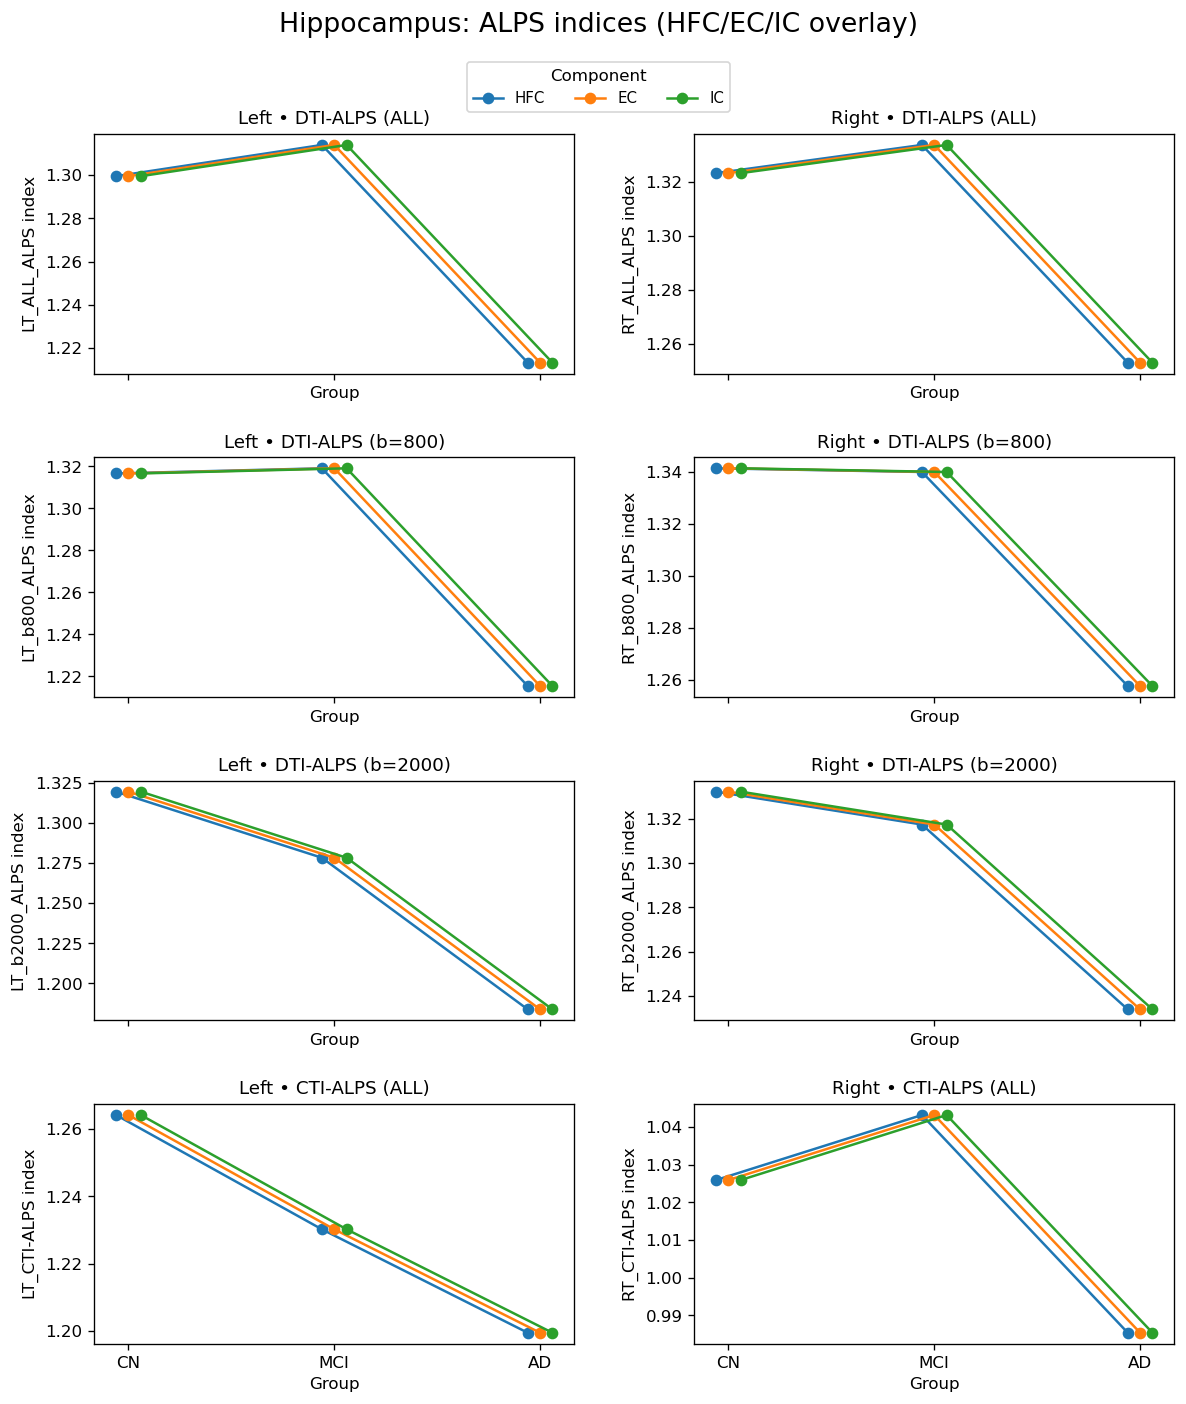

In [27]:
for reg in regions:
    plot_region_figure(df, reg)

plt.show()

In [4]:
map_ddx = {'NL':'CN', 'SaMCI':'*MCI', 'MaMCI':'*MCI', 'AD':'AD'}
dfP = df.copy()
dfP['DDX3'] = dfP['DDX'].map(map_ddx)

group_order = ['AD', '*MCI', 'CN']  # x축 왼→오
row_labels  = ['ALL', 'b=800', 'b=2000', 'CTI']

row_to_alps_col = {
    ('ALL','LT'):   'LT_ALL_ALPS index',
    ('ALL','RT'):   'RT_ALL_ALPS index',
    ('b800','LT'):  'LT_b800_ALPS index',
    ('b800','RT'):  'RT_b800_ALPS index',
    ('b2000','LT'): 'LT_b2000_ALPS index',
    ('b2000','RT'): 'RT_b2000_ALPS index',
    ('CTI','LT'):   'LT_CTI-ALPS index',
    ('CTI','RT'):   'RT_CTI-ALPS index',
}
rows  = [('ALL','DTI-ALPS (ALL)'),
         ('b800','DTI-ALPS (b=800)'),
         ('b2000','DTI-ALPS (b=2000)'),
         ('CTI','CTI-ALPS (ALL)')]
sides = [('LT','LEFT'), ('RT','RIGHT')]

comps   = ['HFC','EC','IC']
# regions = ['Hippocampus','Insula']

def comp_cols(side, region):
    # 예: side='LT', region='Hippocampus'
    return [f'{c}_{side}_{region}' for c in comps]


In [5]:
def plot_region_figure(dfP, region, out=None, figsize=(10, 12), dpi=120):
    """x=DDX3 그룹(AD→*MCI→CN), y=ALPS index(행·열별 선택), 각 서브플롯에 HFC/EC/IC 3라인
       - Figure-level legend (제목 아래 중앙, 한 줄)
       - 상단 행: LT / RT만 표기
       - 각 subplot 내부에 row 제목/ALPS 컬럼명 표기하지 않음
       - y라벨: 왼쪽 열에만 'ALPS index, {row_label}'
    """
    # sharex=False로 모든 subplot에 x tick 라벨 표시
    fig, axes = plt.subplots(4, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    for r, (band, row_title) in enumerate(rows):
        for c, (side, side_title) in enumerate(sides):
            ax = axes[r, c]
            alps_col = row_to_alps_col[(band, side)]
            if alps_col not in dfP.columns:
                ax.axis('off'); continue

            # 필요한 컬럼만 취합 (ALPS + DDX3 + 컴포넌트 3개)
            needed = [alps_col, 'DDX3'] + comp_cols(side, region)
            sub = dfP[needed].copy()

            # 숫자형 변환 (ALPS와 컴포넌트들), DDX3는 카테고리 유지
            for cc in [alps_col] + comp_cols(side, region):
                sub[cc] = pd.to_numeric(sub[cc], errors='coerce')

            sub = sub.dropna(subset=[alps_col, 'DDX3'])
            if sub.empty:
                ax.axis('off'); continue

            grp    = sub.groupby('DDX3')
            y_mean = grp[alps_col].mean().reindex(group_order).dropna()
            x_pos  = np.arange(len(y_mean))  # 0,1,2

            # x축 tick/라벨: 모든 subplot에 표시
            ax.set_xticks(x_pos)
            ax.set_xticklabels(y_mean.index)
            ax.tick_params(axis='x', labelbottom=True)

            # 보조 세로선
            for xv in x_pos:
                ax.axvline(xv, linestyle='--', linewidth=1, alpha=0.35)

            # 3개 컴포넌트 라인 (요구 스펙상 y=ALPS, 동일 y 공유 → x만 오프셋)
            offsets = [-0.12, 0.0, 0.12]
            for i, comp in enumerate(comps):
                col = f'{comp}_{side}_{region}'
                if col not in sub.columns:
                    continue
                yy = y_mean.values  # y=ALPS 그룹 평균
                ax.plot(x_pos + offsets[i], yy, marker='o', label=comp)

            # 상단 행만 LT/RT 표기, 나머지는 제목 없음
            if r == 0:
                ax.set_title(side_title, fontweight='bold', fontstyle='italic', fontsize=12)
            else:
                ax.set_title("")

            # y축 라벨: 왼쪽 열만 'ALPS index, {row_label}'
            if c == 0:
                ax.set_ylabel(f'ALPS index, {row_labels[r]}')
            else:
                ax.set_ylabel('')

            # 하단 행만 x라벨(문구)
            if r == len(rows) - 1:
                ax.set_xlabel('')
            else:
                ax.set_xlabel('')

            ax.set_xlim(-0.5, len(x_pos) - 0.5)

    # 상단 통합 제목
    fig.suptitle(f'{region}: ALPS–Group plot (AD → *MCI → CN)',
                 fontsize=14, fontweight='bold', y=0.965)

    # figure-level legend (제목 아래 중앙, 한 줄)
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        h, lab = ax.get_legend_handles_labels()
        for hh, ll in zip(h, lab):
            if ll and ll not in seen:
                handles.append(hh); labels.append(ll); seen.add(ll)
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.945),
                   ncol=3, title='Components', fontsize=9, frameon=True)

    # 레이아웃(제목/범례 공간 확보)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.88, bottom=0.08,
                        hspace=0.35, wspace=0.25)

    if out:
        pdf_path = os.path.join(out, f'ALPS_group_means_byCond_{region}.pdf')
        fig.savefig(pdf_path)
        print(f'Saved: {pdf_path}')

    plt.show()
    plt.close(fig)

Saved: D:\JHAhn\files\ALPS_group_means_byCond_Hippocampus.pdf


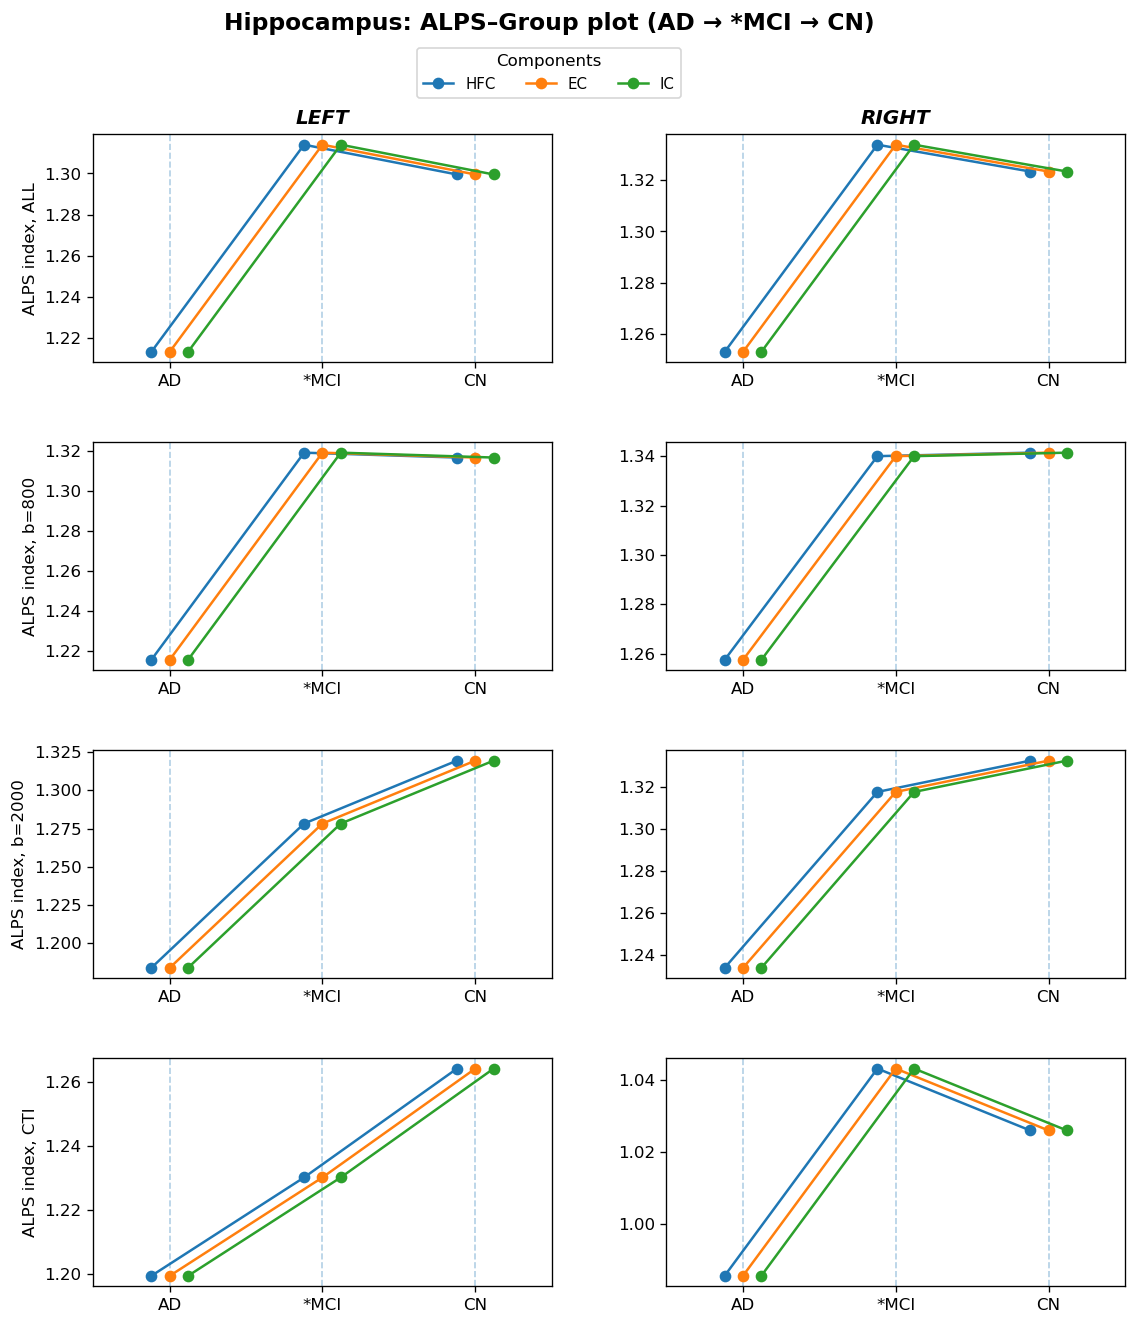

In [7]:
plot_region_figure(dfP, 'Hippocampus', out=base)

Saved: D:\JHAhn\files\ALPS_group_means_byCond_Insula.pdf


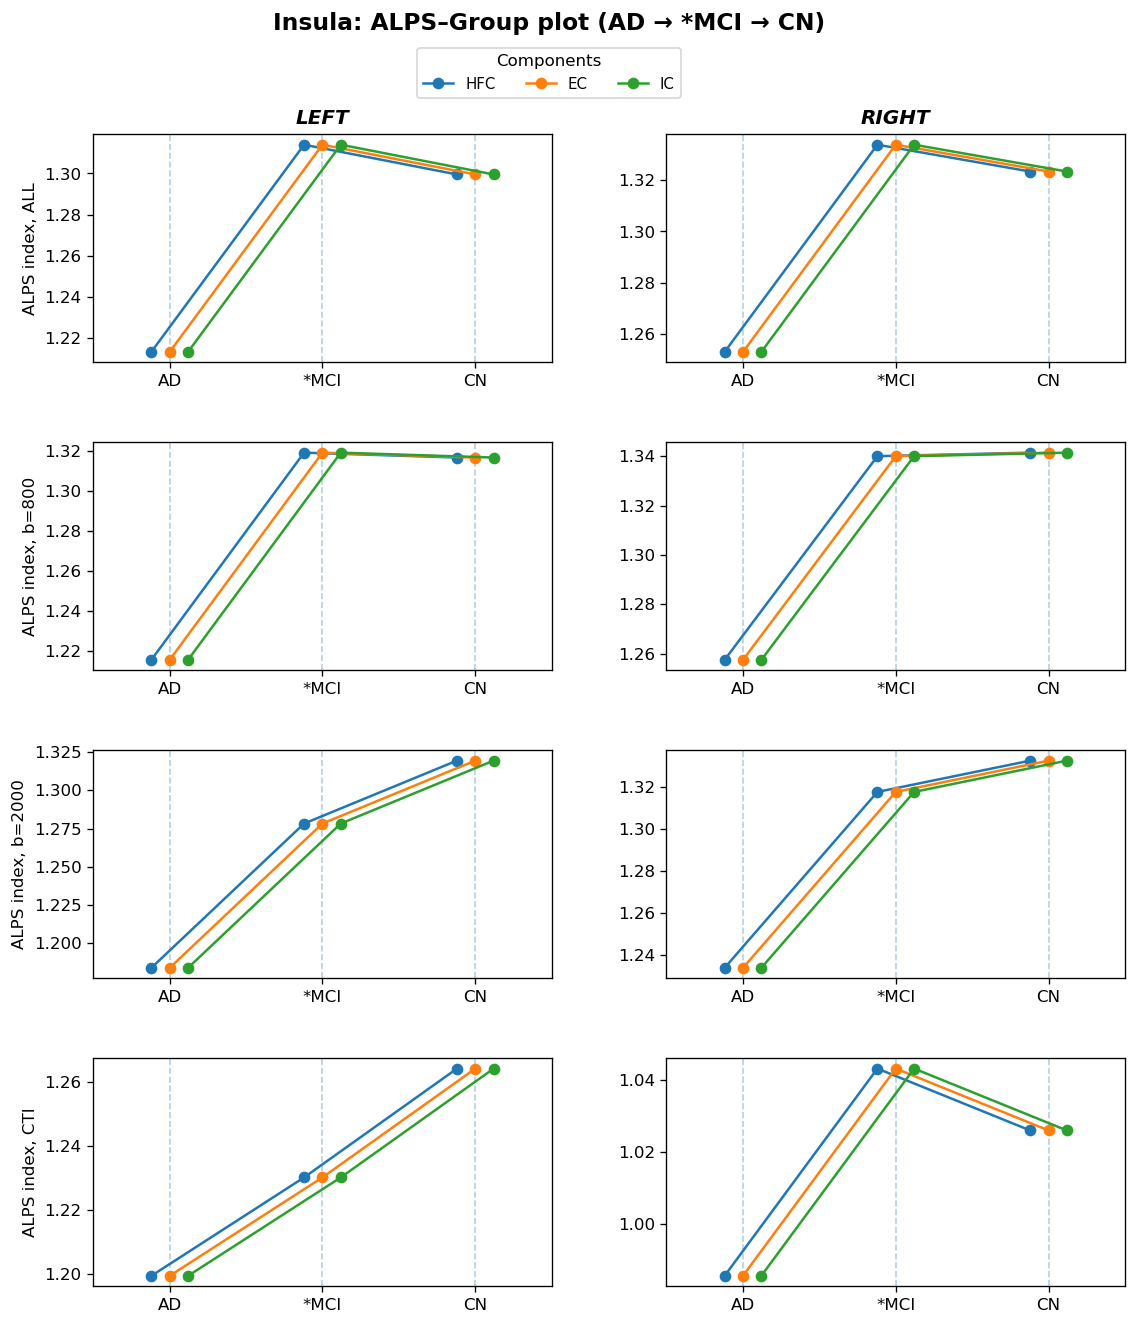

In [6]:
plot_region_figure(dfP, 'Insula', out=base)

In [ ]:
## Plots: ALPS-AGE, ALPS-MMSE

In [8]:
cti_stats = {
    'Age':  {'LT': (-0.215, '0.024'),  'RT': (-0.126, '0.023')},
    'MMSE': {'LT': ( 0.182, '0.057'),  'RT': ( 0.126, '0.191')},
}
# dti_stats = {
#     'LT': {
#         'Age':  {'ALL': (-0.241, '0.015'), 'b=800': (-0.277, '0.005'), 'b=2000': (-0.223, '0.024')},
#         'MMSE': {'ALL': ( 0.212, '0.033'), 'b=800': ( 0.222, '0.025'), 'b=2000': ( 0.214, '0.031')},
#     },
#     'RT': {
#         'Age':  {'ALL': (-0.342, '≤ 0.001'), 'b=800': (-0.365, '≤ 0.001'), 'b=2000': (-0.337, '≤ 0.001')},
#         'MMSE': {'ALL': ( 0.174, '0.081'),    'b=800': ( 0.183, '0.067'),    'b=2000': ( 0.211, '0.034')},
#     }
# }
dti_stats = {
    'LT': {
        'Age':  {'b=800': (-0.381, '≤ 0.001'), 'b=2000': (-0.318, '≤ 0.001')},
        'MMSE': {'b=800': ( 0.222, '0.020'), 'b=2000': ( 0.234, '0.014')},
    },
    'RT': {
        'Age':  {'b=800': (-0.423, '≤ 0.001'), 'b=2000': (-0.407, '≤ 0.001')},
        'MMSE': {'b=800': ( 0.207, '0.030'), 'b=2000': ( 0.257, '0.007')},
    }
}


def _fmt_label(base, r, p):
    """legend용 라벨 포맷터: r은 소수 3자리, p는 '≤ 0.001' 등 특수기호 처리"""
    if isinstance(p, str):
        p_clean = p.strip()
        if p_clean.startswith(('≤', '<', '>')):
            p_text = f"P{p_clean}"         # 예) '≤ 0.001' -> 'P≤ 0.001'
        else:
            p_text = f"P={p_clean}"
    else:
        # 숫자면 0.001 미만은 'P≤ 0.001', 그 외는 'P=0.123'
        try:
            p_val = float(p)
            p_text = "P≤ 0.001" if p_val < 0.001 else f"P={p_val:.3f}"
        except Exception:
            p_text = f"P={p}"

    return f"{base} (r={float(r):.3f}, {p_text})"

In [9]:
# ── 산점도 + 추세선(OLS/빈평균) ───────────────────────────────────────────
def _scatter_with_trend(ax, x, y, label, color=None, s=28, alpha=0.65, lw=2, mode='ols', n_bins=8):
    sub = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                        'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data: {label}", ha='center', va='center',
                transform=ax.transAxes, alpha=0.6)
        return

    # 산점도
    ax.scatter(sub['x'], sub['y'], s=s, alpha=alpha, label=label, color=color)

    if mode == 'ols':
        # 직선(OLS)
        if sub['x'].nunique() < 2:
            x_min, x_max = float(sub['x'].min()), float(sub['x'].max())
            ax.hlines(sub['y'].mean(), x_min, x_max, colors=color, linewidth=lw, alpha=0.9)
            return
        m, b = np.polyfit(sub['x'].values, sub['y'].values, 1)  # y = m x + b
        x_line = np.array([sub['x'].min(), sub['x'].max()], dtype=float)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, color=color, linewidth=lw, alpha=0.9)
    else:
        # 빈 평균선
        x_min, x_max = float(sub['x'].min()), float(sub['x'].max())
        if x_min == x_max:
            return
        bins = np.linspace(x_min, x_max, n_bins + 1)
        cut = pd.cut(sub['x'], bins=bins, include_lowest=True)
        grp = sub.groupby(cut)
        x_mean = grp['x'].mean()
        y_mean = grp['y'].mean()
        mask = x_mean.notna() & y_mean.notna()
        x_line = x_mean[mask].values
        y_line = y_mean[mask].values
        order = np.argsort(x_line)
        ax.plot(x_line[order], y_line[order], linewidth=lw, color=color, alpha=0.9)

# ── 메인 플로팅(좌=Age / 우=MMSE) ─────────────────────────────────────────
def plot_cti_dti_vs_age_mmse(df, figsize=(11, 14), dpi=120, savepath=None, trend='ols', n_bins=8):
    # 숫자형 보정
    for col in ['Age', 'MMSE']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 색상: 요청대로 DTI 'ALL'은 검정
    colors_cti = {'LT': 'C0', 'RT': 'C1'}
    colors_dti = {'b=800': 'C2', 'b=2000': 'C3'}

    # 사용할 컬럼
    # cti_cols = {'LT': 'LT_CTI-ALPS index', 'RT': 'RT_CTI-ALPS index'}
    # dti_cols_LT = {'ALL': 'LT_ALL_ALPS index', 'b=800': 'LT_b800_ALPS index', 'b=2000': 'LT_b2000_ALPS index'}
    # dti_cols_RT = {'ALL': 'RT_ALL_ALPS index', 'b=800': 'RT_b800_ALPS index', 'b=2000': 'RT_b2000_ALPS index'}
    cti_cols = {'LT': 'LT_CTI-ALPS index', 'RT': 'RT_CTI-ALPS index'}
    dti_cols_LT = {'b=800': 'LT_b800_ALPS index', 'b=2000': 'LT_b2000_ALPS index'}
    dti_cols_RT = {'b=800': 'RT_b800_ALPS index', 'b=2000': 'RT_b2000_ALPS index'}

    fig, axes = plt.subplots(3, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    # ── Row 0: CTI  ──────────────────────────────────────────────────────
    # [0,0] CTI vs Age (좌)
    ax = axes[0, 0]
    for side, col in cti_cols.items():
        if col in df.columns:
            r, p = cti_stats['Age'][side]
            label = _fmt_label(side, r, p)
            _scatter_with_trend(ax, df['Age'], df[col], label=label, color=colors_cti[side], mode=trend, n_bins=n_bins)
    ax.set_title('CTI-ALPS vs Age', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(frameon=True)

    # [0,1] CTI vs MMSE (우)
    ax = axes[0, 1]
    for side, col in cti_cols.items():
        if col in df.columns:
            r, p = cti_stats['MMSE'][side]
            label = _fmt_label(side, r, p)
            _scatter_with_trend(ax, df['MMSE'], df[col], label=label, color=colors_cti[side], mode=trend, n_bins=n_bins)
    ax.set_title('CTI-ALPS vs MMSE', fontweight='bold')
    ax.set_xlabel('MMSE'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(frameon=True)

## Row 1: DTI – LT
    # [1,0] LT DTI vs Age (좌)
    ax = axes[1, 0]
    for tag, col in dti_cols_LT.items():
        if col in df.columns:
            r, p = dti_stats['LT']['Age'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['Age'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('LT DTI-ALPS vs Age', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='LT b-value', frameon=True)

    # [1,1] LT DTI vs MMSE (우)
    ax = axes[1, 1]
    for tag, col in dti_cols_LT.items():
        if col in df.columns:
            r, p = dti_stats['LT']['MMSE'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['MMSE'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('LT DTI-ALPS vs MMSE', fontweight='bold')
    ax.set_xlabel('MMSE'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='LT b-value', frameon=True)

## Row 2: DTI – RT
    # [2,0] RT DTI vs Age (좌)
    ax = axes[2, 0]
    for tag, col in dti_cols_RT.items():
        if col in df.columns:
            r, p = dti_stats['RT']['Age'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['Age'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('RT DTI-ALPS vs Age', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='RT b-value', frameon=True)

    # [2,1] RT DTI vs MMSE (우)
    ax = axes[2, 1]
    for tag, col in dti_cols_RT.items():
        if col in df.columns:
            r, p = dti_stats['RT']['MMSE'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['MMSE'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('RT DTI-ALPS vs MMSE', fontweight='bold')
    ax.set_xlabel('MMSE'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='RT b-value', frameon=True)

    fig.suptitle('CTI & DTI ALPS vs Age/MMSE', fontsize=14, y=0.97, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.965])

    if savepath:
        # fig.savefig(savepath)
        fig.savefig(savepath, format='tiff', dpi='figure', bbox_inches='tight')
        print(f"Saved figure to: {savepath}")

    return fig, axes

Saved figure to: D:\JHAhn\files\ALPS_vs_Age_MMSE.tiff


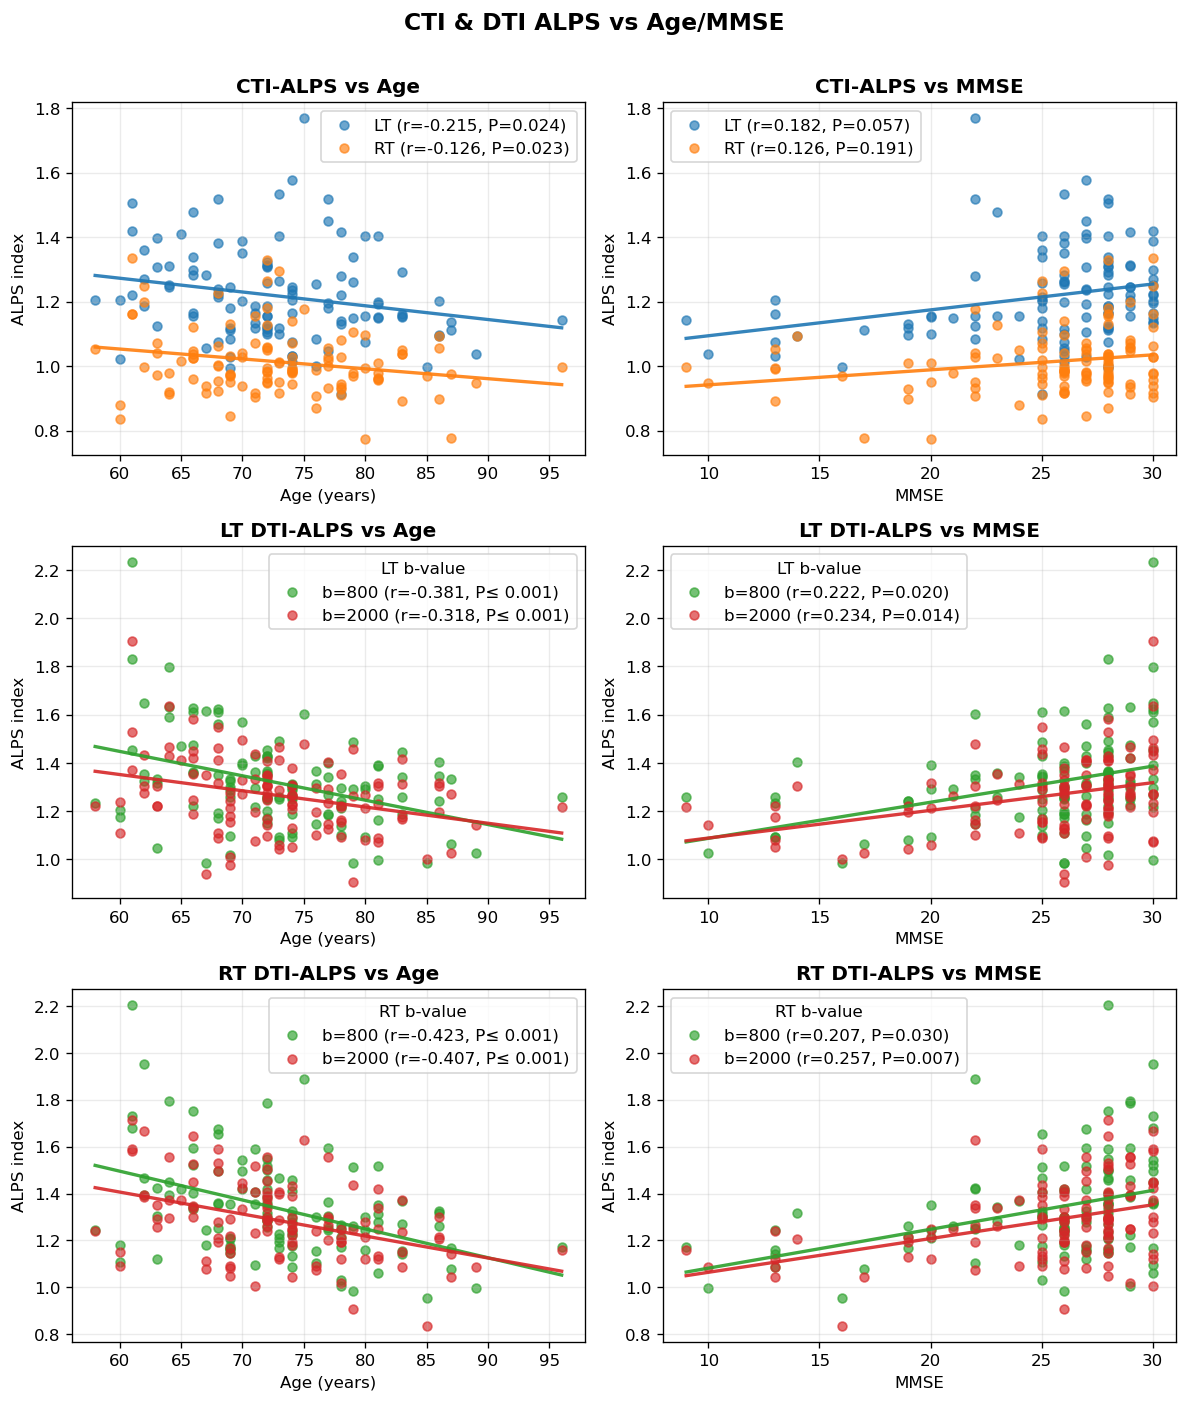

In [12]:
fig, axes = plot_cti_dti_vs_age_mmse(
    df,
    figsize=(10, 12),
    dpi=120,
    trend='ols',   # 'ols' 또는 'bin'
    n_bins=8,      # trend='bin'일 때만 사용
    savepath=os.path.join(base, "ALPS_vs_Age_MMSE.tiff")
)

Saved figure to: D:\JHAhn\files\ALPS_vs_Age_MMSE_bin.pdf


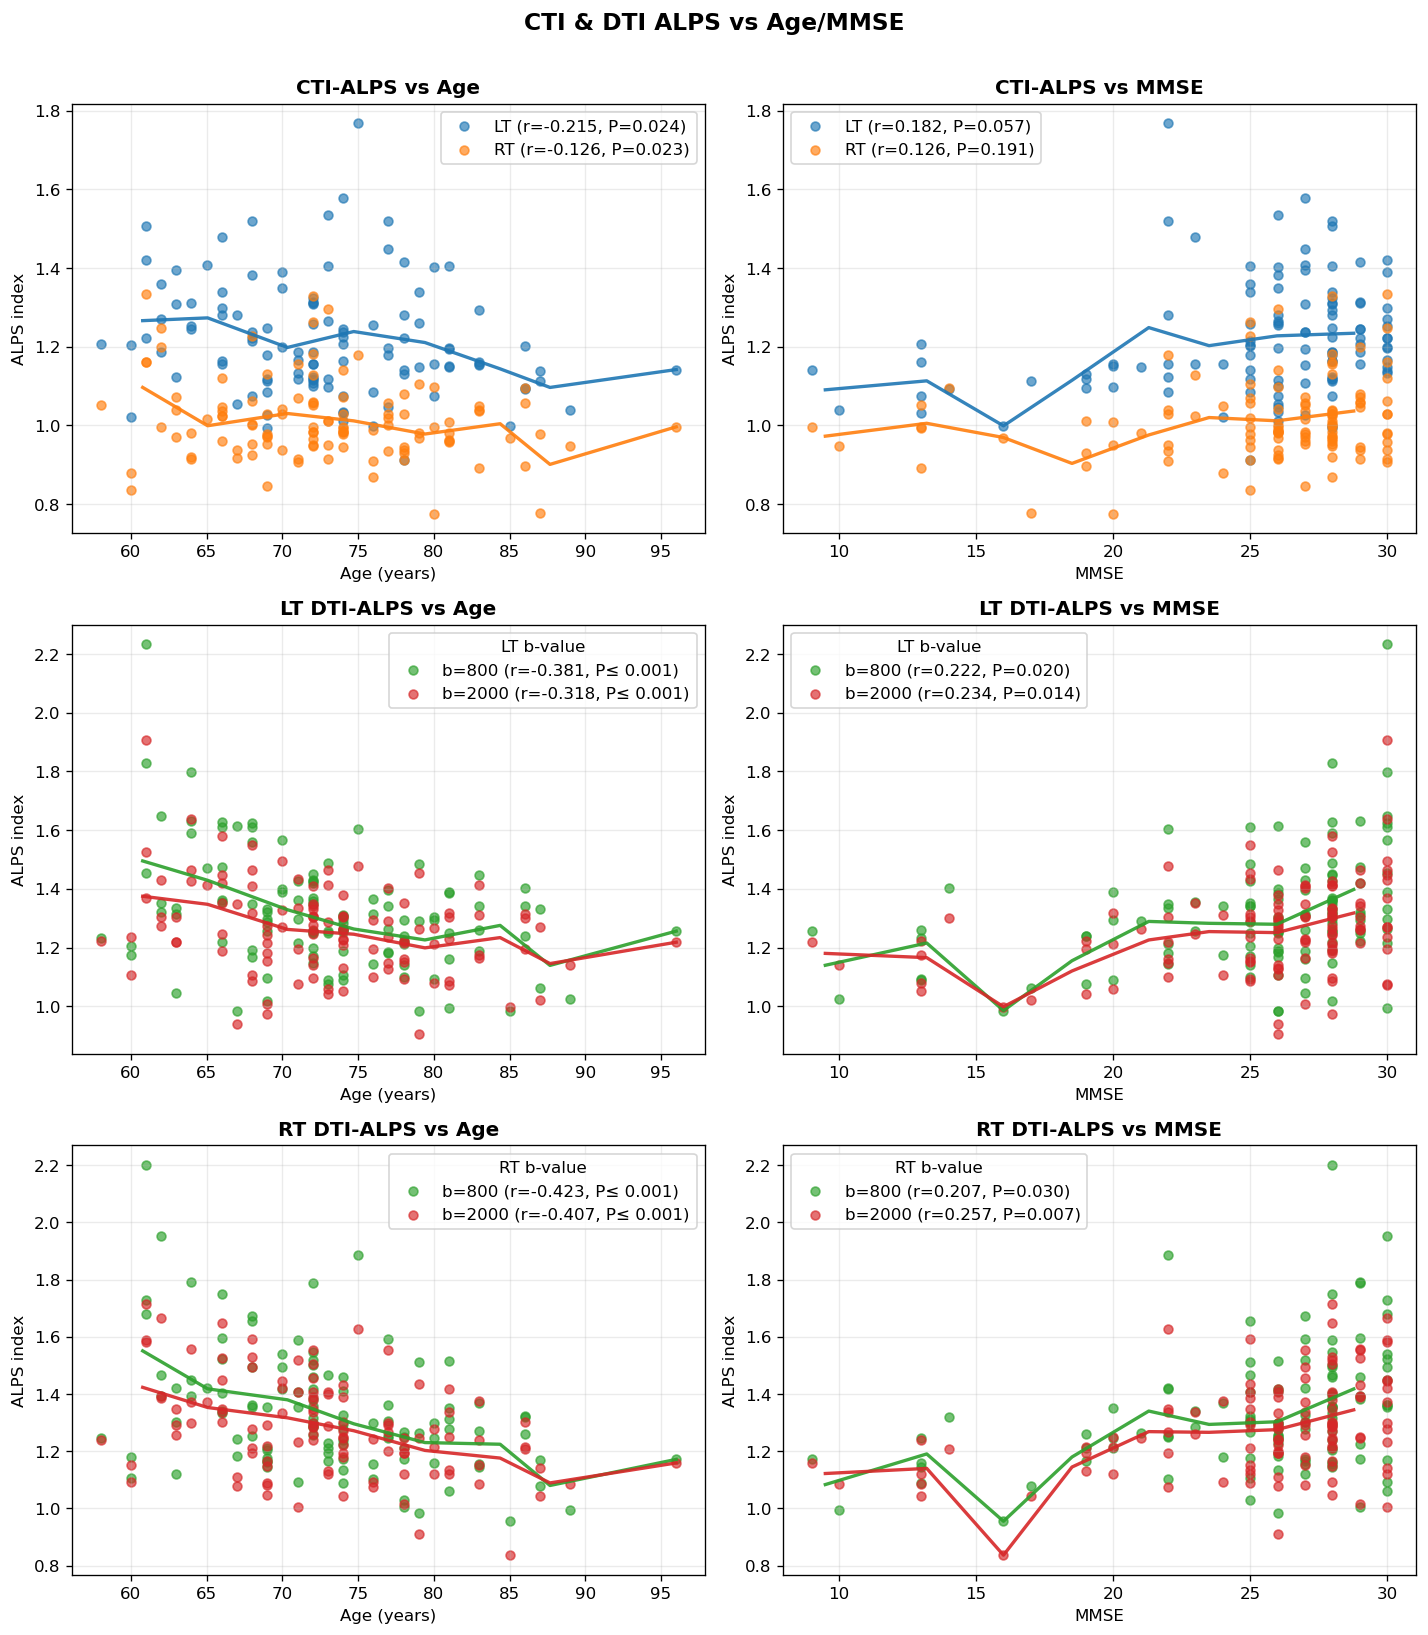

In [11]:
fig, axes = plot_cti_dti_vs_age_mmse(
    df,
    figsize=(12, 14),
    dpi=120,
    trend='bin',   # ols | bin
    n_bins=8,      # trend='bin'일 때만 사용
    savepath=os.path.join(base, "ALPS_vs_Age_MMSE_bin.pdf")
)

In [17]:
dti_cols = [
    'LT_ALL_ALPS index','LT_b800_ALPS index','LT_b2000_ALPS index',
    'RT_ALL_ALPS index','RT_b800_ALPS index','RT_b2000_ALPS index'
]

# 숫자형 강제
for c in dti_cols + ['Age', 'MMSE']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# 1) 컬럼별 기본 요약(존재/개수/범위 등)
summary = []
for c in dti_cols:
    exists = c in df.columns
    if not exists:
        summary.append({
            'column': c, 'exists': False, 'n_nonnull': 0, 'n_null': np.nan,
            'n_unique': np.nan, 'min': np.nan, 'max': np.nan, 'mean': np.nan
        })
        continue
    s = df[c]
    summary.append({
        'column': c,
        'exists': True,
        'n_nonnull': int(s.notna().sum()),
        'n_null':   int(s.isna().sum()),
        'n_unique': int(s.nunique(dropna=True)),
        'min':      float(s.min(skipna=True)) if s.notna().any() else np.nan,
        'max':      float(s.max(skipna=True)) if s.notna().any() else np.nan,
        'mean':     float(s.mean(skipna=True)) if s.notna().any() else np.nan,
    })
summary_df = pd.DataFrame(summary).sort_values(['exists','column'], ascending=[False, True]).reset_index(drop=True)

# 2) 플롯용 유효쌍 개수(각 지표 vs Age / vs MMSE 에서 dropna 후 남는 행 수)
pairs = []
for c in dti_cols:
    if c in df.columns:
        n_age  = df[['Age',  c]].dropna().shape[0]
        n_mmse = df[['MMSE', c]].dropna().shape[0]
    else:
        n_age = n_mmse = 0
    pairs.append({'column': c, 'valid_pairs_with_Age': n_age, 'valid_pairs_with_MMSE': n_mmse})
pairs_df = pd.DataFrame(pairs)

# 3) 좌/우 각각에서 3개(bands)가 모두 결측인 케이스 수
left_all_nan  = int(df[['LT_ALL_ALPS index','LT_b800_ALPS index','LT_b2000_ALPS index']].isna().all(axis=1).sum())
right_all_nan = int(df[['RT_ALL_ALPS index','RT_b800_ALPS index','RT_b2000_ALPS index']].isna().all(axis=1).sum())

print("=== DTI-ALPS columns summary ===")
display(summary_df)
print("\n=== Valid pair counts (for plotting) ===")
display(pairs_df)
print(f"\nRows with ALL LT DTI-ALPS missing:  {left_all_nan}")
print(f"Rows with ALL RT DTI-ALPS missing:  {right_all_nan}")

=== DTI-ALPS columns summary ===


,column,exists,n_nonnull,n_null,n_unique,min,max,mean
0,LT_ALL_ALPS index,True,102,0,101,0.981989,1.685871,1.285864
1,LT_b2000_ALPS index,True,102,0,101,0.965916,2.355150,1.268516
2,LT_b800_ALPS index,True,102,0,101,0.980882,1.690331,1.293890
3,RT_ALL_ALPS index,True,102,0,101,0.921116,1.857494,1.311616
4,RT_b2000_ALPS index,True,102,0,101,0.989289,1.970150,1.302288
5,RT_b800_ALPS index,True,102,0,101,0.923851,1.859350,1.320998



=== Valid pair counts (for plotting) ===


,column,valid_pairs_with_Age,valid_pairs_with_MMSE
0,LT_ALL_ALPS index,102,102
1,LT_b800_ALPS index,102,102
2,LT_b2000_ALPS index,102,102
3,RT_ALL_ALPS index,102,102
4,RT_b800_ALPS index,102,102
5,RT_b2000_ALPS index,102,102



Rows with ALL LT DTI-ALPS missing:  0
Rows with ALL RT DTI-ALPS missing:  0


In [15]:
## Ratios <--> Age, MMSE

ratio_specs = [
    ("Insula HFC / Hippocampus Volume",      "R_LT_insulaHFC-HippoVol",  "R_RT_insulaHFC-HippoVol"),
    ("Insula EC / Hippocampus Volume",       "R_LT_insulaEC-HippoVol",   "R_RT_insulaEC-HippoVol"),
    ("Hippocampus HFC / Hippocampus Volume", "R_LT_HippoHFC-HippoVol",   "R_RT_HippoHFC-HippoVol"),
    ("Hippocampus EC / Hippocampus Volume",  "R_LT_HippoEC-HippoVol",    "R_RT_HippoEC-HippoVol"),
    ("Insula HFC / Insula Volume",           "R_LT_InsulaHFC-InsulaVol", "R_RT_InsulaHFC-InsulaVol"),
    ("Insula EC / Insula Volume",            "R_LT_InsulaEC-InsulaVol",  "R_RT_InsulaEC-InsulaVol"),
]

# 2) 제공된 상관 통계 (문자 그대로 사용)
ratio_stats = {
    "Insula HFC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.521, "≤ 0.001"), "RT": ( 0.542, "≤ 0.001")},
        "MMSE": {"LT": (-0.393, "≤ 0.001"), "RT": (-0.405, "≤ 0.001")},
    },
    "Insula EC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.528, "≤ 0.001"), "RT": ( 0.547, "≤ 0.001")},
        "MMSE": {"LT": (-0.417, "≤ 0.001"), "RT": (-0.399, "≤ 0.001")},
    },
    "Hippocampus HFC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.448, "≤ 0.001"), "RT": ( 0.463, "≤ 0.001")},
        "MMSE": {"LT": (-0.274, "0.006"),   "RT": (-0.308, "0.006")},
    },
    "Hippocampus EC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.494, "≤ 0.001"), "RT": ( 0.512, "≤ 0.001")},
        "MMSE": {"LT": (-0.408, "≤ 0.001"), "RT": (-0.468, "≤ 0.001")},
    },
    "Insula HFC / Insula Volume": {
        "Age":  {"LT": ( 0.530, "≤ 0.001"), "RT": ( 0.532, "≤ 0.001")},
        "MMSE": {"LT": (-0.406, "≤ 0.001"), "RT": (-0.442, "≤ 0.001")},
    },
    "Insula EC / Insula Volume": {
        "Age":  {"LT": ( 0.523, "≤ 0.001"), "RT": ( 0.539, "≤ 0.001")},
        "MMSE": {"LT": (-0.432, "≤ 0.001"), "RT": (-0.435, "≤ 0.001")},
    },
}

def _fmt_label(base, r, p):
    """legend용 라벨 포맷터: r은 소수 3자리, p는 '≤ 0.001' 등 특수기호 처리"""
    if isinstance(p, str):
        p_clean = p.strip()
        if p_clean.startswith(('≤', '<', '>')):
            p_text = f"P{p_clean}"         # 예) '≤ 0.001' -> 'P≤ 0.001'
        else:
            p_text = f"P={p_clean}"
    else:
        # 숫자면 0.001 미만은 'P≤ 0.001', 그 외는 'P=0.123'
        try:
            p_val = float(p)
            p_text = "P≤ 0.001" if p_val < 0.001 else f"P={p_val:.3f}"
        except Exception:
            p_text = f"P={p}"

    return f"{base} (r={float(r):.3f}, {p_text})"

In [119]:
def plot_ratio_age_mmse_overlay(df, figsize=(12, 24), dpi=120, savepath=None):
    # 숫자형 보정
    for col in ['Age', 'MMSE']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    colors_side = {'LT': 'C0', 'RT': 'C1'}

    n_rows = len(ratio_specs)
    fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=figsize, dpi=dpi,
                             sharex=False, sharey=False)

    # ── 메인 루프 ────────────────────────────────────────────────────────
    for r, (title, lt_col, rt_col) in enumerate(ratio_specs):
        # 행 공통 y범위
        yvals = []
        for c_name in (lt_col, rt_col):
            if c_name in df.columns:
                yvals.append(pd.to_numeric(df[c_name], errors='coerce'))
        y_all = pd.concat(yvals, axis=0).dropna() if yvals else pd.Series(dtype=float)
        ylim_row = None
        if not y_all.empty:
            y_min, y_max = float(y_all.min()), float(y_all.max())
            pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
            ylim_row = (y_min - pad, y_max + pad)

        # 두 열: 0=Age, 1=MMSE (각 축에 LT·RT를 함께)
        for c, xvar in enumerate(('Age', 'MMSE')):
            ax = axes[r, c]

            # LT
            if lt_col in df.columns:
                r_val, p_val = ratio_stats[title][xvar]['LT']
                label = _fmt_label('LT', r_val, p_val)
                _scatter_with_trend(ax, df[xvar], df[lt_col], label=label, color=colors_side['LT'])
            else:
                ax.text(0.5, 0.5, f"Missing: {lt_col}", ha='center', va='center',
                        transform=ax.transAxes, alpha=0.7)

            # RT
            if rt_col in df.columns:
                r_val, p_val = ratio_stats[title][xvar]['RT']
                label = _fmt_label('RT', r_val, p_val)
                _scatter_with_trend(ax, df[xvar], df[rt_col], label=label, color=colors_side['RT'])
            else:
                ax.text(0.5, 0.4, f"Missing: {rt_col}", ha='center', va='center',
                        transform=ax.transAxes, alpha=0.7)

            # ── subplot 제목: 가운데 정렬, 1pt 크게, 여백 확대
            ax.set_title(title, loc='center', fontsize=12, pad=10)

            ax.grid(True, alpha=0.25)
            if ylim_row:
                ax.set_ylim(ylim_row)

            # 축 라벨: 좌열만 y라벨, x라벨은 모두 제거(열 헤더만 사용)
            if c == 0:
                ax.set_ylabel('Ratio index')
            else:
                ax.set_ylabel('')
            ax.set_xlabel('')  # ← 하단의 작은 Age/MMSE 라벨 완전 제거

            ax.legend(frameon=True, fontsize=9, loc='upper right')

    # ── 레이아웃: subplot 높이 키우고, 행 간격(hspace) 줄임 ────────────────
    fig.subplots_adjust(left=0.065, right=0.975, top=0.92, bottom=0.06,
                        hspace=0.4, wspace=0.15)

    # 열 제목 'Age' / 'MMSE'를 축 밖(fig-level)에 배치(겹침 방지)
    posL = axes[0, 0].get_position()
    posR = axes[0, 1].get_position()
    ycol = max(posL.y1, posR.y1) + 0.02  # 축 위 살짝
    fig.text((posL.x0 + posL.x1) / 2, ycol, 'Age',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')
    fig.text((posR.x0 + posR.x1) / 2, ycol, 'MMSE',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')

    fig.suptitle('Ratio indices vs Age (left) and MMSE (right)',
                 fontsize=14, fontweight='bold', y=0.98)

    if savepath:
        fig.savefig(savepath)
        print(f"Saved: {savepath}")

    return fig, axes

Saved: D:\JHAhn\files\Ratio_Age_MMSE_overlay.pdf


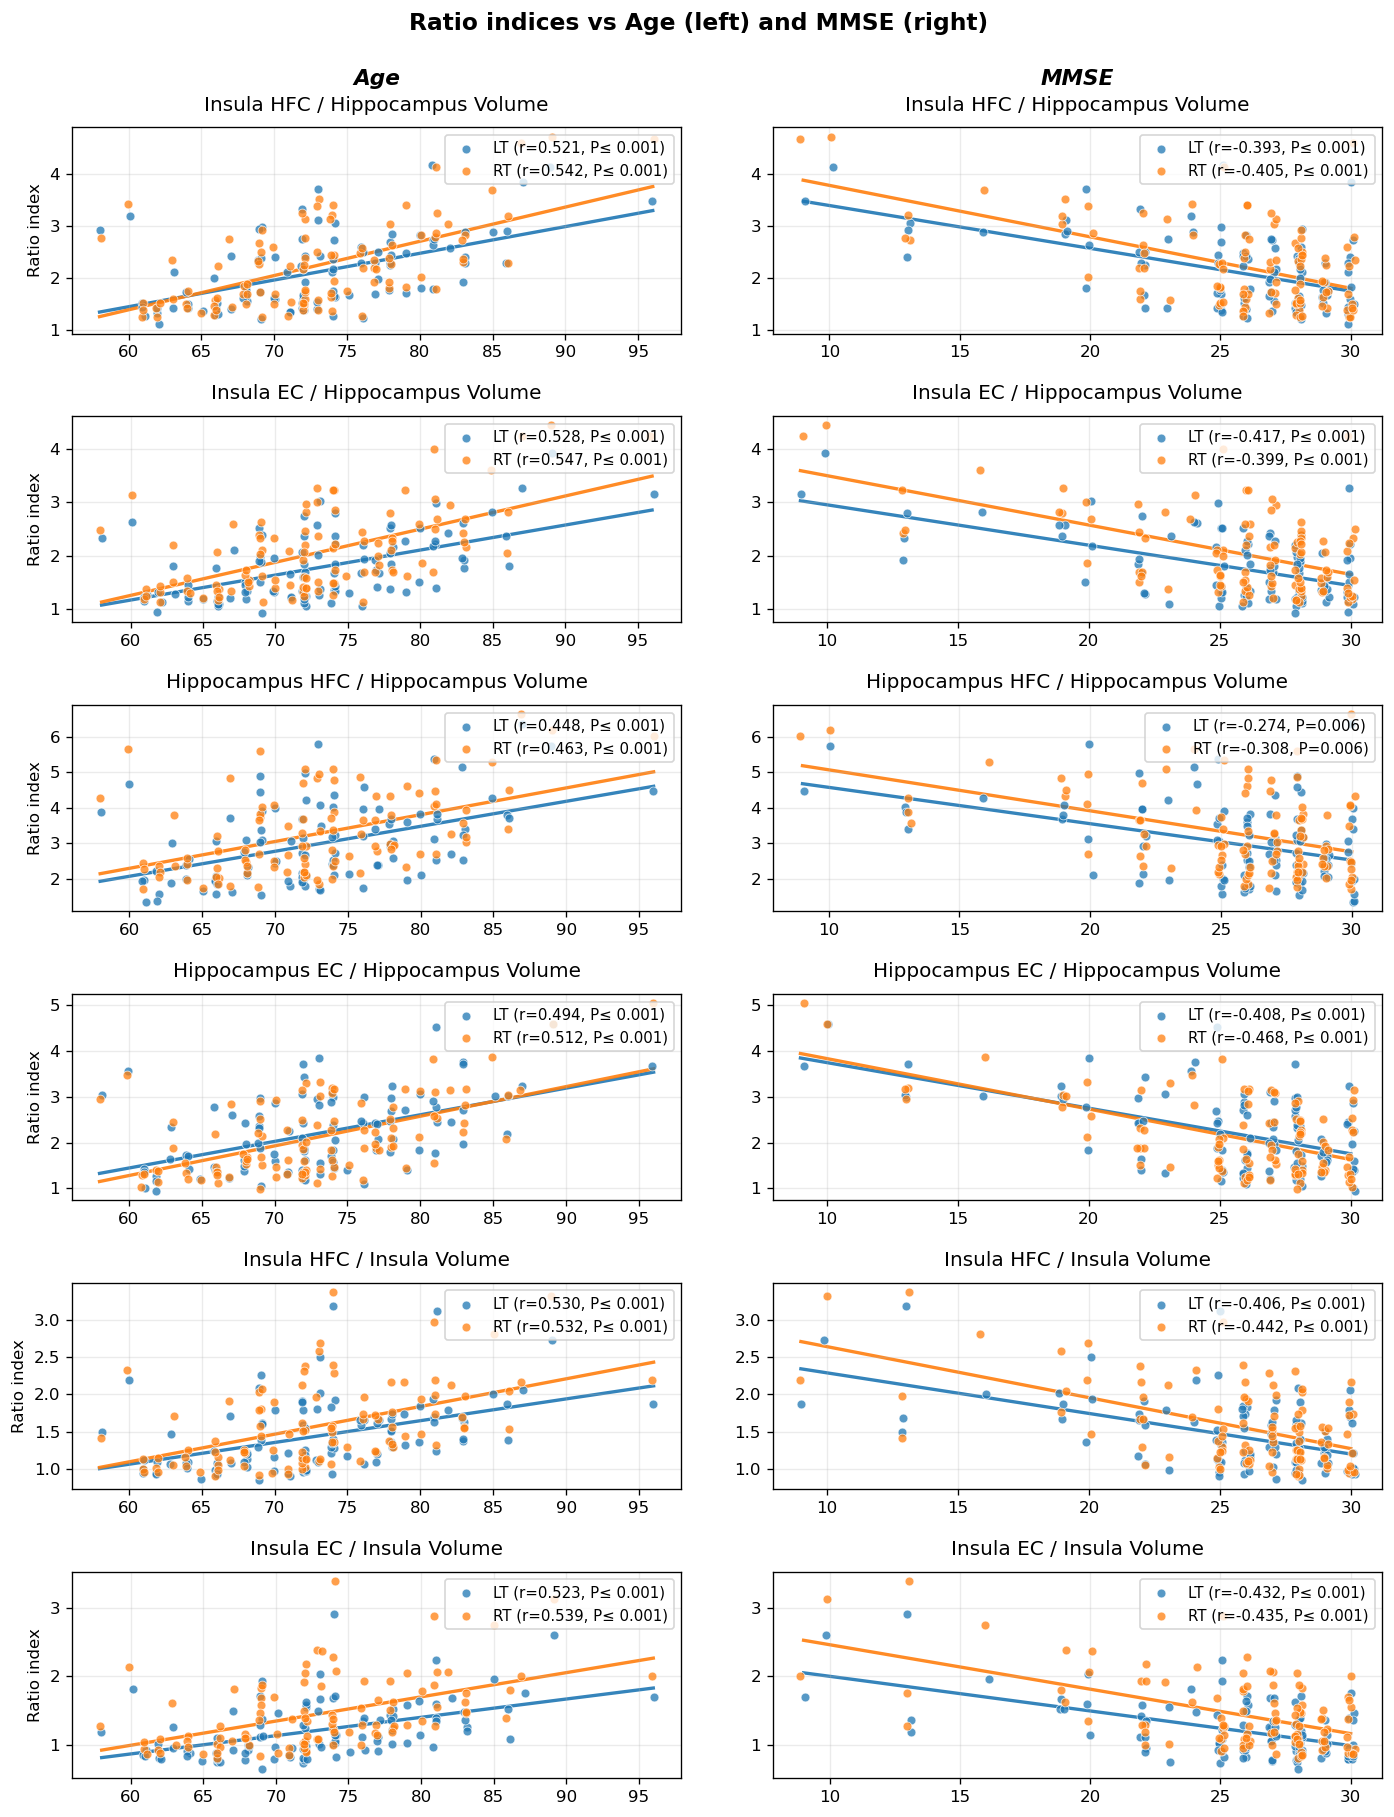

In [120]:
fig, axes = plot_ratio_age_mmse_overlay(
    df,
    figsize=(12, 16),
    dpi=120,
    savepath=os.path.join(base, "Ratio_Age_MMSE_overlay.pdf")
)

In [13]:
math_titles = {
    # Insula HFC / Hippocampus Volume
    "Insula HFC / Hippocampus Volume":
        r"$\mathit{\mathbf{R}}_{\mathit{\mathbf{Ins/Hippo}}}:\;\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Insula}}}/\mathit{\mathbf{V}}_{\mathit{\mathbf{Hippo}}}$",

    # Hippocampus HFC / Hippocampus Volume
    "Hippocampus HFC / Hippocampus Volume":
        r"$\mathit{\mathbf{R}}_{\mathit{\mathbf{Hippo}}}:\;\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Hippo}}}/\mathit{\mathbf{V}}_{\mathit{\mathbf{Hippo}}}$",

    # Insula HFC / Insula Volume
    "Insula HFC / Insula Volume":
        r"$\mathit{\mathbf{R}}_{\mathit{\mathbf{Insula}}}:\;\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Insula}}}/\mathit{\mathbf{V}}_{\mathit{\mathbf{Insula}}}$",
}

ratio_specs = [
    ("Insula HFC / Hippocampus Volume",      "R_LT_insulaHFC-HippoVol",  "R_RT_insulaHFC-HippoVol"),
    ("Hippocampus HFC / Hippocampus Volume", "R_LT_HippoHFC-HippoVol",   "R_RT_HippoHFC-HippoVol"),
    ("Insula HFC / Insula Volume",           "R_LT_InsulaHFC-InsulaVol", "R_RT_InsulaHFC-InsulaVol"),
]

ratio_stats = {
    "Insula HFC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.568, "≤ 0.001"), "RT": ( 0.595, "≤ 0.001")},
        "MMSE": {"LT": (-0.391, "≤ 0.001"), "RT": (-0.433, "≤ 0.001")},
    },
    "Hippocampus HFC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.515, "≤ 0.001"), "RT": ( 0.498, "≤ 0.001")},
        "MMSE": {"LT": (-0.242, "0.011"),   "RT": (-0.291, "0.002")},
    },
    "Insula HFC / Insula Volume": {
        "Age":  {"LT": ( 0.473, "≤ 0.001"), "RT": ( 0.500, "≤ 0.001")},
        "MMSE": {"LT": (-0.392, "≤ 0.001"), "RT": (-0.425, "≤ 0.001")},
    },
}

def _fmt_label(base, r, p):
    if isinstance(p, str):
        p_clean = p.strip()
        p_text = f"P{p_clean}" if p_clean.startswith(('≤', '<', '>')) else f"P={p_clean}"
    else:
        try:
            p_val = float(p)
            p_text = "P≤ 0.001" if p_val < 0.001 else f"P={p_val:.3f}"
        except Exception:
            p_text = f"P={p}"
    return f"{base} (r={float(r):.3f}, {p_text})"

def _scatter_with_trend(ax, x, y, label, color=None, s=28, alpha=0.75, lw=2, mode='ols', n_bins=8):
    sub = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                        'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data: {label}", ha='center', va='center',
                transform=ax.transAxes, alpha=0.65)
        return

    ax.scatter(sub['x'], sub['y'], s=s, alpha=alpha, label=label, color=color)

    if mode == 'ols':
        if sub['x'].nunique() < 2:
            x_min, x_max = float(sub['x'].min()), float(sub['x'].max())
            ax.hlines(sub['y'].mean(), x_min, x_max, colors=color, linewidth=lw, alpha=0.9)
            return
        m, b = np.polyfit(sub['x'].values, sub['y'].values, 1)
        x_line = np.array([sub['x'].min(), sub['x'].max()], dtype=float)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, color=color, linewidth=lw, alpha=0.9)
    else:
        x_min, x_max = float(sub['x'].min()), float(sub['x'].max())
        if x_min == x_max:
            return
        bins = np.linspace(x_min, x_max, n_bins + 1)
        cut = pd.cut(sub['x'], bins=bins, include_lowest=True)
        grp = sub.groupby(cut)
        x_mean = grp['x'].mean(); y_mean = grp['y'].mean()
        mask = x_mean.notna() & y_mean.notna()
        xx = x_mean[mask].values; yy = y_mean[mask].values
        ax.plot(np.sort(xx), yy[np.argsort(xx)], linewidth=lw, color=color, alpha=0.9)

def plot_ratio_age_mmse_overlay(
    df, figsize=(11, 14), dpi=120, savepath=None,
    trend='ols', n_bins=8, specs=None, stats_map=None
):
    if specs is None:
        specs = [
            ("Insula HFC / Hippocampus Volume",      "R_LT_insulaHFC-HippoVol",  "R_RT_insulaHFC-HippoVol"),
            ("Hippocampus HFC / Hippocampus Volume", "R_LT_HippoHFC-HippoVol",   "R_RT_HippoHFC-HippoVol"),
            ("Insula HFC / Insula Volume",           "R_LT_InsulaHFC-InsulaVol", "R_RT_InsulaHFC-InsulaVol"),
        ]
    if stats_map is None:
        stats_map = ratio_stats

    for col in ['Age', 'MMSE']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    colors_side = {'LT': 'C0', 'RT': 'C1'}
    fig, axes = plt.subplots(3, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    for r, (title, lt_col, rt_col) in enumerate(specs):
        for c, xvar in enumerate(('Age', 'MMSE')):
            ax = axes[r, c]

            if lt_col in df.columns:
                r_val, p_val = stats_map.get(title, {}).get(xvar, {}).get('LT', (np.nan, np.nan))
                _scatter_with_trend(ax, df[xvar], df[lt_col],
                                    label=_fmt_label('LT', r_val, p_val),
                                    color=colors_side['LT'], mode=trend, n_bins=n_bins)
            if rt_col in df.columns:
                r_val, p_val = stats_map.get(title, {}).get(xvar, {}).get('RT', (np.nan, np.nan))
                _scatter_with_trend(ax, df[xvar], df[rt_col],
                                    label=_fmt_label('RT', r_val, p_val),
                                    color=colors_side['RT'], mode=trend, n_bins=n_bins)
            ax.set_title(math_titles.get(title, title), fontweight='bold', fontstyle='italic', pad=8)

            if c == 0:
                ax.set_xlabel('Age (years)')
            else:
                ax.set_xlabel('MMSE')

            ax.set_ylabel('Ratio index' if c == 0 else '')
            ax.grid(True, alpha=0.25)
            ax.legend(frameon=True)

    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, hspace=0.30, wspace=0.18)
    
    posL = axes[0, 0].get_position()
    posR = axes[0, 1].get_position()
    ycol = max(posL.y1, posR.y1) + 0.0275
    fig.text((posL.x0 + posL.x1) / 2, ycol, 'Age',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')
    fig.text((posR.x0 + posR.x1) / 2, ycol, 'MMSE',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')

    fig.suptitle('Ratio indices vs Age and MMSE', fontsize=14, fontweight='bold', y=0.96)

    if savepath:
        fig.savefig(savepath, format='tiff', dpi='figure', bbox_inches='tight')
        print(f"Saved figure to: {savepath}")

    return fig, axes

Saved figure to: D:\JHAhn\files\HFC_Ratios_vs_Age_MMSE.tiff


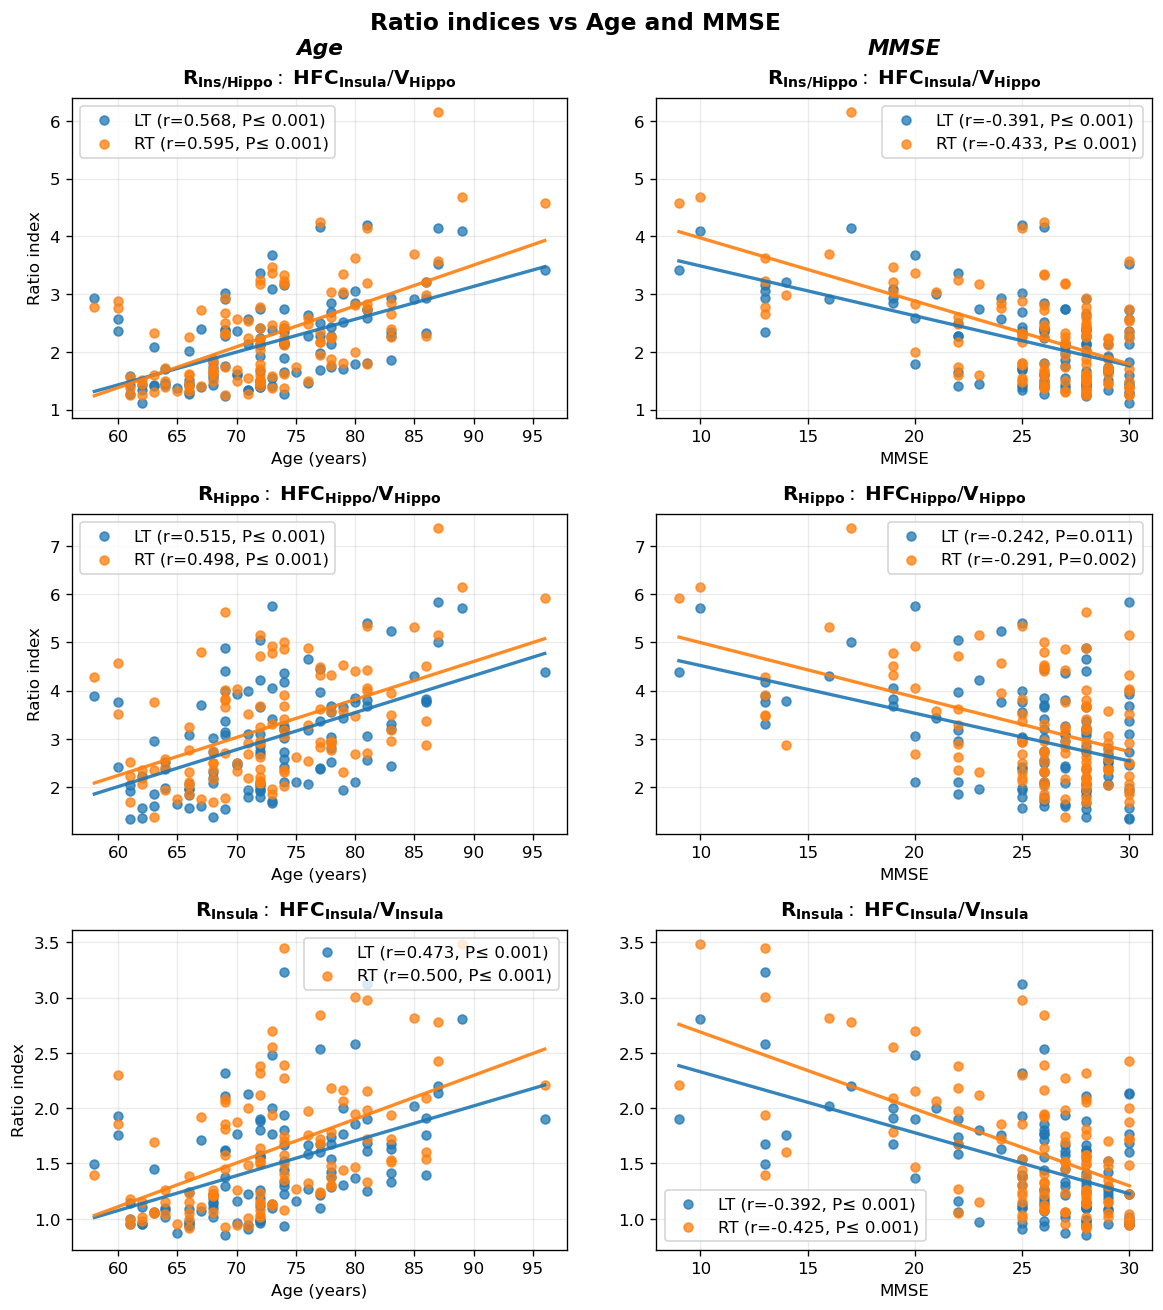

In [15]:
fig, axes = plot_ratio_age_mmse_overlay(
    df, figsize=(10,12), dpi=120,
    trend='ols', n_bins=8,
    savepath=os.path.join(base, "HFC_Ratios_vs_Age_MMSE.tiff")
)

In [5]:
def _scatter_with_trend(ax, x, y, label, color=None, s=28, alpha=0.75, lw=2):
    sub = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                        'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data: {label}", ha='center', va='center',
                transform=ax.transAxes, alpha=0.65)
        return
    ax.scatter(sub['x'], sub['y'], s=s, alpha=alpha, color=color, label=label)
    if sub['x'].nunique() >= 2:
        m, b = np.polyfit(sub['x'].values, sub['y'].values, 1)
        xx = np.array([sub['x'].min(), sub['x'].max()], dtype=float)
        yy = m * xx + b
        ax.plot(xx, yy, color=color, linewidth=lw, alpha=0.9)
    else:
        ax.hlines(sub['y'].mean(), float(sub['x'].min()), float(sub['x'].max()),
                  colors=color, linewidth=lw, alpha=0.9)

def _fmt_label_comp(base, r, p):
    if isinstance(p, str):
        p_clean = p.strip().replace('≤', '≤ ').replace('<', '< ').replace('>','> ')
        p_clean = ' '.join(p_clean.split())  # 공백 정리
        p_text = f"P{p_clean}" if p_clean.startswith(('≤','<','>')) else f"P={p_clean}"
    else:
        try:
            p_val = float(p)
            p_text = "P≤ 0.001" if p_val < 0.001 else f"P={p_val:.3f}"
        except Exception:
            p_text = f"P={p}"
    return f"{base} (r={float(r):.3f}, {p_text})"

## Column maps
# DTI columns
DTI_MAP = {
    'LT': {
        'Projection': {
            'b=800':  {'Dxx': 'LT_b800_Dxx_proj',  'Dyy': 'LT_b800_Dyy_proj',  'Dzz': 'LT_b800_Dzz_proj'},
            'b=2000': {'Dxx': 'LT_b2000_Dxx_proj', 'Dyy': 'LT_b2000_Dyy_proj', 'Dzz': 'LT_b2000_Dzz_proj'},
        },
        'Association': {
            'b=800':  {'Dxx': 'LT_b800_Dxx_assoc',  'Dyy': 'LT_b800_Dyy_assoc',  'Dzz': 'LT_b800_Dzz_assoc'},
            'b=2000': {'Dxx': 'LT_b2000_Dxx_assoc', 'Dyy': 'LT_b2000_Dyy_assoc', 'Dzz': 'LT_b2000_Dzz_assoc'},
        },
    },
    'RT': {
        'Projection': {
            'b=800':  {'Dxx': 'RT_b800_Dxx_proj',  'Dyy': 'RT_b800_Dyy_proj',  'Dzz': 'RT_b800_Dzz_proj'},
            'b=2000': {'Dxx': 'RT_b2000_Dxx_proj', 'Dyy': 'RT_b2000_Dyy_proj', 'Dzz': 'RT_b2000_Dzz_proj'},
        },
        'Association': {
            'b=800':  {'Dxx': 'RT_b800_Dxx_assoc',  'Dyy': 'RT_b800_Dyy_assoc',  'Dzz': 'RT_b800_Dzz_assoc'},
            'b=2000': {'Dxx': 'RT_b2000_Dxx_assoc', 'Dyy': 'RT_b2000_Dyy_assoc', 'Dzz': 'RT_b2000_Dzz_assoc'},
        },
    },
}

# CTI columns
CTI_MAP = {
    'LT': {
        'Projection':  {'Dxx': 'LT_CTI_Proj_Dxx',  'Dyy': 'LT_CTI_Proj_Dyy',  'Dzz': 'LT_CTI_Proj_Dzz'},
        'Association': {'Dxx': 'LT_CTI_Assoc_Dxx', 'Dyy': 'LT_CTI_Assoc_Dyy', 'Dzz': 'LT_CTI_Assoc_Dzz'},
    },
    'RT': {
        'Projection':  {'Dxx': 'RT_CTI_Proj_Dxx',  'Dyy': 'RT_CTI_Proj_Dyy',  'Dzz': 'RT_CTI_Proj_Dzz'},
        'Association': {'Dxx': 'RT_CTI_Assoc_Dxx', 'Dyy': 'RT_CTI_Assoc_Dyy', 'Dzz': 'RT_CTI_Assoc_Dzz'},
    },
}

## STAT maps
CTI_DTI_COMP_STATS = {
    'LT': {
        'Projection': {
            'b=800':  {'Dxx': (0.167, '0.094'),   'Dyy': (0.366, '< 0.001'), 'Dzz': (0.053, '0.597')},
            'b=2000': {'Dxx': (0.355, '< 0.001'), 'Dyy': (0.489, '< 0.001'), 'Dzz': (0.224, '0.024')},
        },
        'Association': {
            'b=800':  {'Dxx': (0.304, '0.002'),   'Dyy': (-0.015, '0.882'),  'Dzz': (0.258, '0.009')},
            'b=2000': {'Dxx': (0.459, '< 0.001'), 'Dyy': (0.321, '< 0.001'), 'Dzz': (0.393, '< 0.001')},
        },
    },
    'RT': {
        'Projection': {
            'b=800':  {'Dxx': (0.310, '0.002'),   'Dyy': (0.548, '< 0.001'), 'Dzz': (0.274, '0.005')},
            'b=2000': {'Dxx': (0.452, '< 0.001'), 'Dyy': (0.660, '< 0.001'), 'Dzz': (0.421, '< 0.001')},
        },
        'Association': {
            'b=800':  {'Dxx': (0.120, '0.229'),   'Dyy': (0.057, '0.567'),   'Dzz': (0.313, '0.001')},
            'b=2000': {'Dxx': (0.345, '< 0.001'), 'Dyy': (0.347, '< 0.001'), 'Dzz': (0.493, '< 0.001')},
        },
    },
}

In [16]:
def _scatter_points(ax, x, y, label, color=None, s=28, alpha=0.75):
    sub = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                        'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data: {label}", ha='center', va='center',
                transform=ax.transAxes, alpha=0.65)
        return
    ax.scatter(sub['x'], sub['y'], s=s, alpha=alpha, color=color, label=label)


def plot_cti_dti_compartment_corr(df, figsize=(12, 16), dpi=120, savepath=None,
                                  stats=CTI_DTI_COMP_STATS):
    for side in ['LT','RT']:
        for fib in ['Projection','Association']:
            for b in ['b=800','b=2000']:
                for comp in ['Dxx','Dyy','Dzz']:
                    dcol = DTI_MAP[side][fib][b][comp]
                    ccol = CTI_MAP[side][fib][comp]
                    if dcol in df.columns:
                        df[dcol] = pd.to_numeric(df[dcol], errors='coerce')
                    if ccol in df.columns:
                        df[ccol] = pd.to_numeric(df[ccol], errors='coerce')

    comp_colors = {'Dxx': 'C0', 'Dyy': 'C1', 'Dzz': 'C2'}
    fig, axes = plt.subplots(4, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    row_specs = [
        ('LT', 'Projection'),
        ('LT', 'Association'),
        ('RT', 'Projection'),
        ('RT', 'Association'),
    ]
    col_specs = ['b=800', 'b=2000']

    for r, (side, fiber) in enumerate(row_specs):
        axes[r, 0].set_ylabel(f'{side}, CTI {fiber}', fontweight='bold')
        axes[r, 1].set_ylabel('')
        for c, btag in enumerate(col_specs):
            ax = axes[r, c]
            for comp in ['Dxx','Dyy','Dzz']:
                dcol = DTI_MAP[side][fiber][btag][comp]
                ccol = CTI_MAP[side][fiber][comp]
                if (dcol not in df.columns) or (ccol not in df.columns):
                    continue
                r_val, p_val = stats.get(side, {}).get(fiber, {}).get(btag, {}).get(comp, (np.nan, np.nan))
                label = _fmt_label_comp(comp, r_val, p_val)
                _scatter_points(ax, df[dcol], df[ccol], label=label, color=comp_colors[comp])

            ax.grid(True, alpha=0.25)
            ax.legend(frameon=True, fontsize=8, loc='best')
            ax.set_xlabel(f"{side}, DTI {fiber} ({btag})")

    fig.tight_layout(rect=[0.06, 0.06, 0.95, 0.90])

    posL = axes[0, 0].get_position()
    posR = axes[0, 1].get_position()
    ycol = max(posL.y1, posR.y1) + 0.01
    fig.text((posL.x0 + posL.x1) / 2, ycol, 'b=800',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')
    fig.text((posR.x0 + posR.x1) / 2, ycol, 'b=2000',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')
    fig.suptitle('CTI vs DTI Tensor Compartments (by component)',
                 fontsize=14, fontweight='bold', y=min(ycol + 0.04, 0.99))

    if savepath:
        fig.savefig(savepath, dpi='figure', bbox_inches='tight')
        print(f"Saved: {savepath}")

    return fig, axes

NameError: name 'CTI_DTI_COMP_STATS' is not defined

Saved: D:\JHAhn\files\CTI+DTI_compartments.tiff


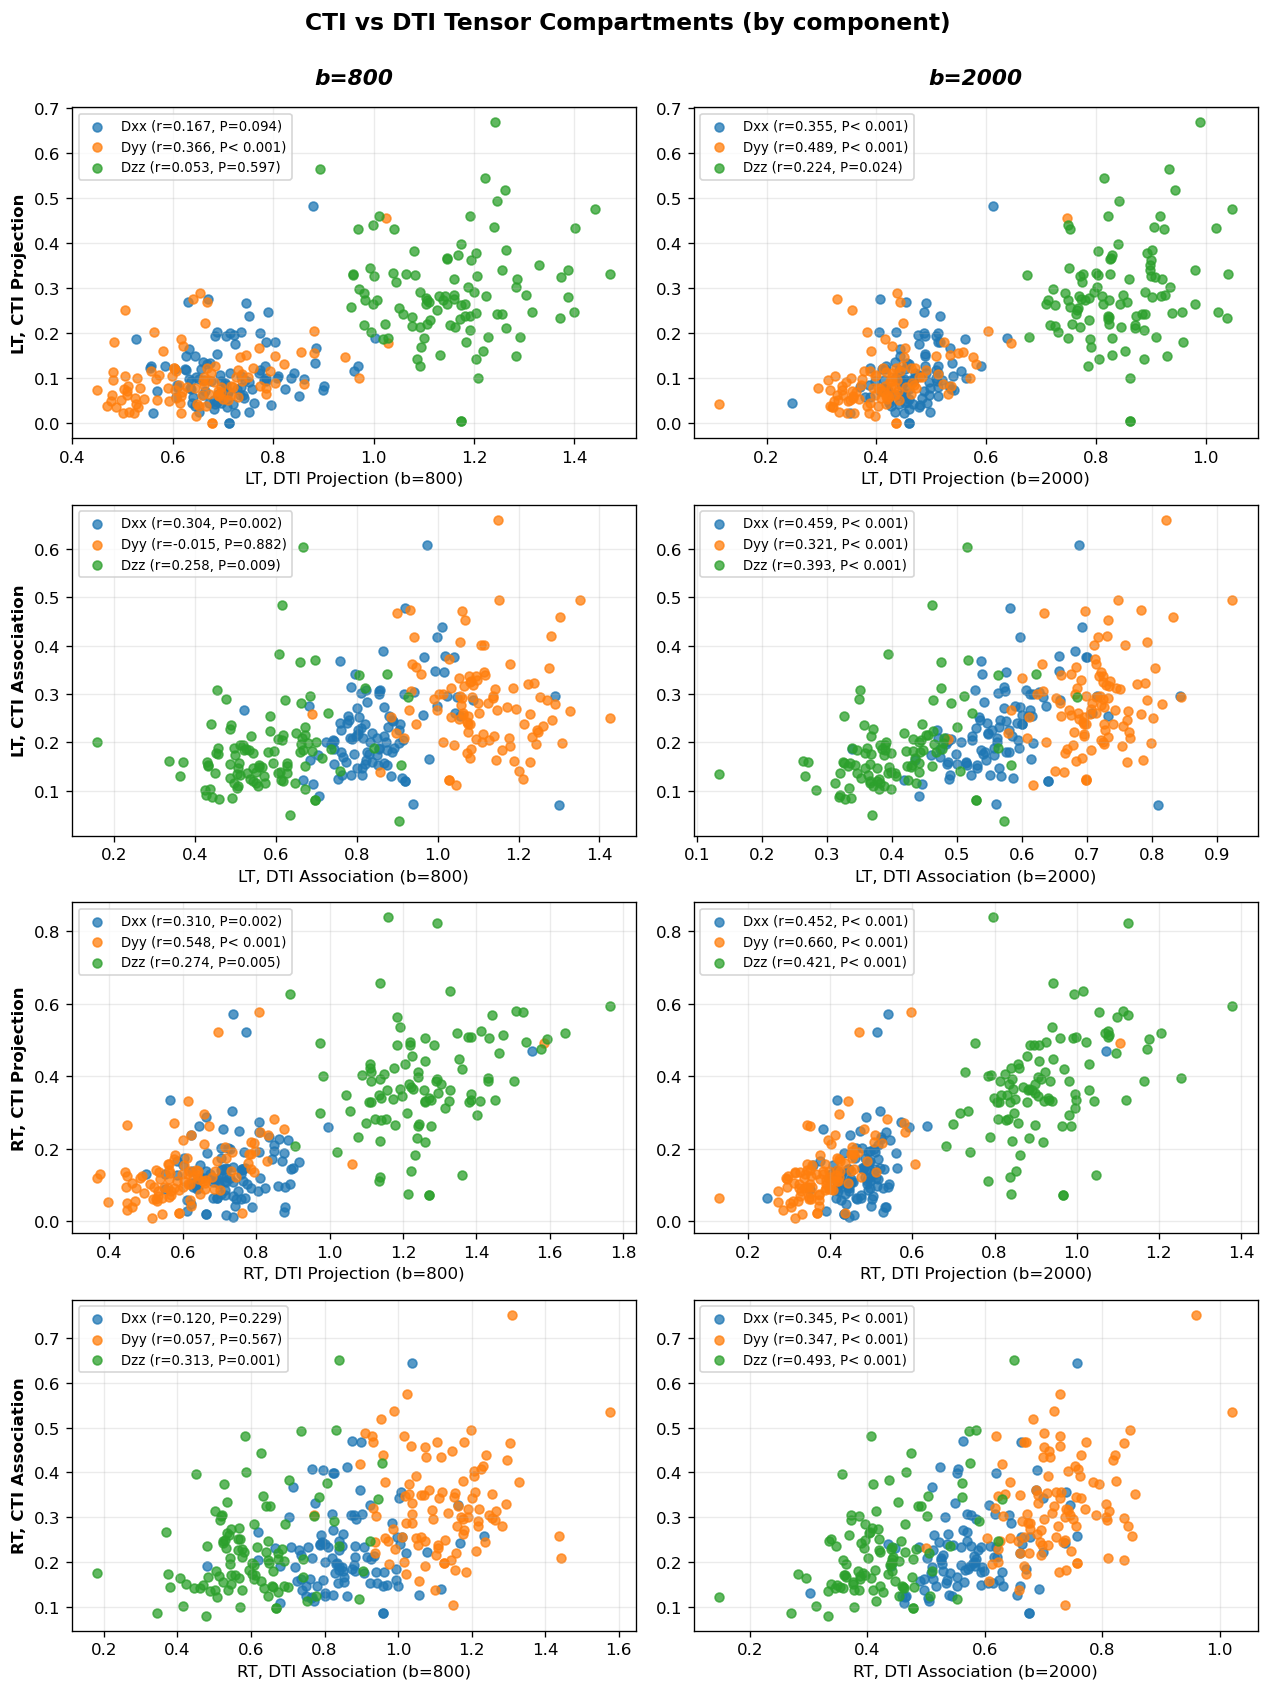

In [37]:
fig, axes = plot_cti_dti_compartment_corr(
    df,
    figsize=(12, 16),
    dpi=120,
    savepath=os.path.join(base, "CTI+DTI_compartments.tiff")
)

In [27]:
hfc_vol_math_titles = {
    "HFC Hippocampus":
        r"$\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Hippo}}}$",
    "HFC Insula":
        r"$\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Insula}}}$",
    "Volume Hippocampus":
        r"$\mathit{\mathbf{V}}_{\mathit{\mathbf{Hippo}}}$",
    "Volume Insula":
        r"$\mathit{\mathbf{V}}_{\mathit{\mathbf{Insula}}}$",
}

# 상관계수 map (이미 써둔 값 재사용)
hfc_vol_stats = {
    # High-frequency conductivity (HFC)
    "HFC Hippocampus": {
        "Age":  {"LT": ( 0.284, "0.003"),    "RT": ( 0.148, "0.123")},
        "MMSE": {"LT": (-0.062, "0.522"),    "RT": (-0.035, "0.720")},
    },
    "HFC Insula": {
        "Age":  {"LT": ( 0.380, "≤ 0.001"),  "RT": ( 0.493, "≤ 0.001")},
        "MMSE": {"LT": (-0.361, "≤ 0.001"),  "RT": (-0.398, "≤ 0.001")},
    },
    # Tissue volume
    "Volume Hippocampus": {
        "Age":  {"LT": (-0.562, "≤ 0.001"),  "RT": (-0.556, "≤ 0.001")},
        "MMSE": {"LT": ( 0.261, "0.006"),     "RT": ( 0.300, "0.001")},
    },
    "Volume Insula": {
        "Age":  {"LT": (-0.501, "≤ 0.001"),  "RT": (-0.484, "≤ 0.001")},
        "MMSE": {"LT": ( 0.277, "0.003"),     "RT": ( 0.285, "0.003")},
    },
}

# --- HFC 전용 specs (2행) ---
hfc_specs = [
    ("HFC Hippocampus", "HFC_LT_Hippocampus", "HFC_RT_Hippocampus"),
    ("HFC Insula",      "HFC_LT_Insula",      "HFC_RT_Insula"),
]

# --- Volume 전용 specs (2행) ---
vol_specs = [
    ("Volume Hippocampus", "LT_Hippocampus",   "RT_Hippocampus"),
    ("Volume Insula",      "LT_Insula_CTX",    "RT_Insula_CTX"),
]

# Plotting functions
def plot_feature_age_mmse_grid(
    df,
    specs,
    stats_map,
    math_titles,
    figsize=(10, 9),   # 2행×2열 정도라 조금 줄였음
    dpi=120,
    savepath=None,
    trend='ols',
    n_bins=8,
    suptitle='Features vs Age and MMSE'
):
    """
    specs: [(title, LT_col, RT_col), ...]
    rows = len(specs), cols = 2 (Age, MMSE)
    """
    # Age / MMSE 숫자형 변환
    for col in ['Age', 'MMSE']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    n_rows = len(specs)
    colors_side = {'LT': 'C0', 'RT': 'C1'}

    fig, axes = plt.subplots(
        n_rows, 2, figsize=figsize, dpi=dpi,
        sharex=False, sharey=False
    )

    # n_rows==1인 경우 axes shape 처리
    if n_rows == 1:
        axes = np.array([axes])

    for r, (title, lt_col, rt_col) in enumerate(specs):
        for c, xvar in enumerate(('Age', 'MMSE')):
            ax = axes[r, c]

            # LT
            if lt_col in df.columns:
                r_val, p_val = stats_map.get(title, {}).get(xvar, {}).get('LT', (np.nan, np.nan))
                _scatter_with_trend(
                    ax,
                    df[xvar],
                    df[lt_col],
                    label=_fmt_label('LT', r_val, p_val),
                    color=colors_side['LT'],
                    mode=trend,
                    n_bins=n_bins
                )

            # RT
            if rt_col in df.columns:
                r_val, p_val = stats_map.get(title, {}).get(xvar, {}).get('RT', (np.nan, np.nan))
                _scatter_with_trend(
                    ax,
                    df[xvar],
                    df[rt_col],
                    label=_fmt_label('RT', r_val, p_val),
                    color=colors_side['RT'],
                    mode=trend,
                    n_bins=n_bins
                )

            # 제목: "{Feature} vs AGE/MMSE"
            base_title = math_titles.get(title, title)
            suffix = xvar.upper()  # "AGE" / "MMSE"
            ax.set_title(
                f"{base_title} vs {suffix}",
                fontweight='bold',
                fontstyle='italic',
                pad=8
            )

            # 축 라벨
            ax.set_xlabel('Age (years)' if xvar == 'Age' else 'MMSE')
            if c == 0:
                ax.set_ylabel('HFC / Volume')
            else:
                ax.set_ylabel('')

            ax.grid(True, alpha=0.25)
            ax.legend(frameon=True)

    fig.subplots_adjust(
        left=0.08, right=0.98,
        top=0.90, bottom=0.10,
        hspace=0.30, wspace=0.18
    )
    fig.suptitle(suptitle, fontsize=14,
                 fontweight='bold', y=0.96)

    if savepath:
        fig.savefig(savepath, format='tiff',
                    dpi='figure', bbox_inches='tight')
        print(f"Saved figure to: {savepath}")

    return fig, axes

Saved figure to: D:\JHAhn\files\Fig1-1_Correlation_HFC_vs_Age_MMSE.tiff


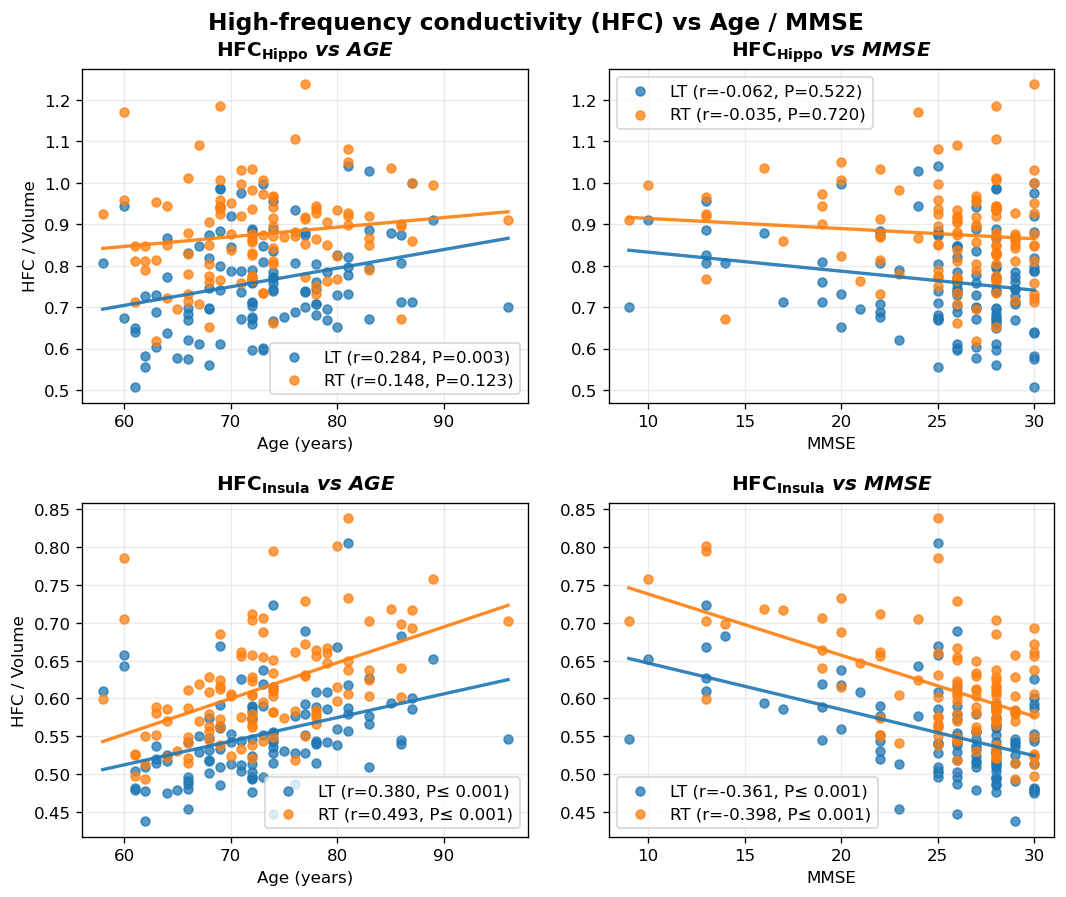

In [39]:
# 1) HFC (Hippocampus + Insula) vs Age/MMSE
fig_hfc, axes_hfc = plot_feature_age_mmse_grid(
    df=df,
    specs=hfc_specs,
    stats_map=hfc_vol_stats,
    math_titles=hfc_vol_math_titles,
    figsize=(9, 8),
    dpi=120,
    trend='ols',
    n_bins=8,
    suptitle='High-frequency conductivity (HFC) vs Age / MMSE',
    savepath=os.path.join(base, "Fig1-1_Correlation_HFC_vs_Age_MMSE.tiff"),
)

Saved figure to: D:\JHAhn\files\Fig1-2_Correlation_TiV_vs_Age_MMSE.tiff


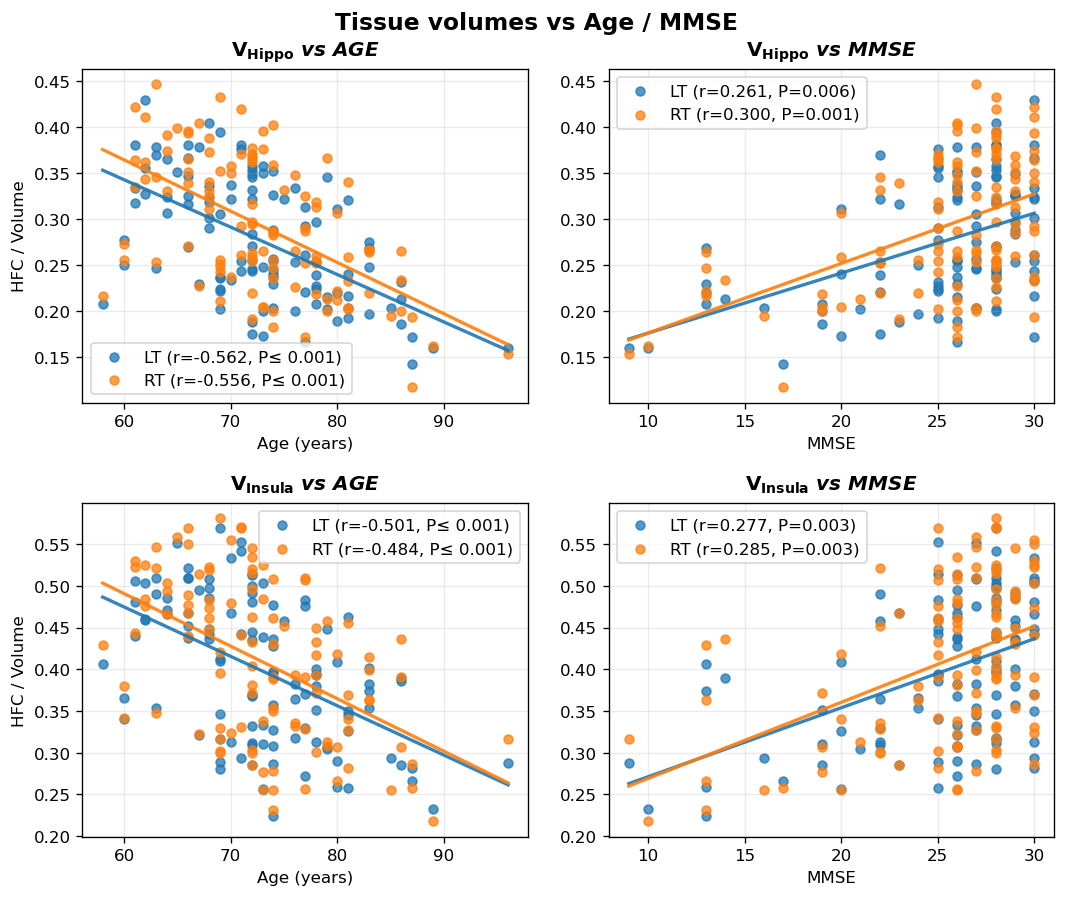

In [40]:
# 2) Volume (Hippocampus + Insula) vs Age/MMSE
fig_vol, axes_vol = plot_feature_age_mmse_grid(
    df=df,
    specs=vol_specs,
    stats_map=hfc_vol_stats,
    math_titles=hfc_vol_math_titles,
    figsize=(9, 8),
    dpi=120,
    trend='ols',
    n_bins=8,
    suptitle='Tissue volumes vs Age / MMSE',
    savepath=os.path.join(base, "Fig1-2_Correlation_TiV_vs_Age_MMSE.tiff"),
)

In [76]:
group_col   = 'Group'          # 네 데이터에 맞게 수정
group_order = [0, 1, 2]        # [CN, MCI, AD]
group_labels = {0: 'CN', 1: 'MCI', 2: 'AD'}

alps_cols = {
    'LT b=800' : 'LT_b800_ALPS index',
    'RT b=800' : 'RT_b800_ALPS index',
    'LT b=2000': 'LT_b2000_ALPS index',
    'RT b=2000': 'RT_b2000_ALPS index',
}

# --- 2) Table의 Statistics 행을 dict로 정리 (p>=0.05는 생략 가능) ---

# 키: ALPS 컬럼명, 값: {(group1, group2): p, ...}
# (Table 내용)
stats_pairs = {
    'LT_b800_ALPS index':   {(1, 3): 0.0458},
    'RT_b800_ALPS index':   {},                   # 유의한 쌍 없음
    'LT_b2000_ALPS index':  {(1, 3): 0.0411},
    'RT_b2000_ALPS index':  {(1, 3): 0.0430},
}

In [77]:
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''


def annotate_sig(ax, x1, x2, y_bottom, p, step):
    """
    x1, x2 : 두 그룹의 x좌표
    y_bottom : 브래킷의 아랫선 y좌표 (이미 outlier 위로 결정된 값)
    step : 레벨 간 높이 간격
    브래킷 모양: 각 끝이 위로 꺾인 'ㄷ'자.
    """
    star = p_to_star(p)
    if not star:
        return

    # 브래킷 높이
    h_vert = 0.4 * step          # 수직선 높이
    y_top = y_bottom + h_vert    # 윗선 y좌표

    # ㄷ 모양 브래킷
    ax.plot([x1, x1, x2, x2],
            [y_bottom, y_top, y_top, y_bottom],
            color='k', linewidth=1.4)

    # 별표는 브래킷 위로 여유 있게
    y_text = y_top + 0.25 * step
    ax.text((x1 + x2) / 2, y_text, star,
            ha='center', va='bottom',
            fontsize=14, fontweight='bold')


def plot_dti_alps_box_with_stats(
    df,
    group_col='Group',
    group_order=(0, 1, 2),
    group_labels=None,
    alps_cols=None,
    stats_pairs=None,
    figsize=(10, 8),
    savepath=None
):
    if group_labels is None:
        group_labels = {g: str(g) for g in group_order}
    if alps_cols is None or stats_pairs is None:
        raise ValueError("alps_cols와 stats_pairs를 지정해야 합니다.")

    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=120)
    axes = axes.ravel()

    # 군 색 (CN, MCI, AD)
    group_colors = {
        group_order[0]: '#4C72B0',  # CN
        group_order[1]: '#DD8452',  # MCI
        group_order[2]: '#55A868',  # AD
    }

    for ax, (title, col) in zip(axes, alps_cols.items()):
        if col not in df.columns:
            ax.text(0.5, 0.5, f"{col} not found",
                    ha='center', va='center', transform=ax.transAxes)
            continue

        # --- 그룹별 데이터 --- #
        data = []
        positions = []
        colors_for_boxes = []
        for i, g in enumerate(group_order, start=1):
            vals = pd.to_numeric(df.loc[df[group_col] == g, col],
                                 errors='coerce').dropna()
            data.append(vals.values)
            positions.append(i)
            colors_for_boxes.append(group_colors.get(g, '#AAAAAA'))

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=0.6,
            patch_artist=True
        )
        for patch, col_box in zip(bp['boxes'], colors_for_boxes):
            patch.set_facecolor(col_box)
            patch.set_alpha(0.85)

        ax.set_xticks(positions)
        ax.set_xticklabels([group_labels[g] for g in group_order])
        for lab in ax.get_xticklabels():
            lab.set_fontweight('bold')
            lab.set_fontsize(10)

        ax.set_ylabel('ALPS index')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # --- 유의한 쌍 브래킷 + 별표 --- #
        pair_dict = stats_pairs.get(col, {})
        sig_pairs = [(pair, p) for pair, p in pair_dict.items() if p < 0.05]

        if sig_pairs and any(len(v) > 0 for v in data):
            all_vals = np.concatenate([v for v in data if len(v) > 0])
            y_data_max = np.max(all_vals)

            ymin, ymax = ax.get_ylim()
            orig_yrange = ymax - ymin if ymax > ymin else 1.0

            n_pairs = len(sig_pairs)
            # outlier 위로 margin 확보
            margin = 0.08 * orig_yrange
            step = 0.08 * orig_yrange
            start_y = y_data_max + margin

            # 브래킷/별표까지 포함한 새 ylim 설정
            new_ymax = start_y + (n_pairs + 2) * step
            ax.set_ylim(ymin, new_ymax)

            # Table의 (1,2,3) → 실제 group 코드 매핑
            map13 = {1: group_order[0], 2: group_order[1], 3: group_order[2]}

            for i_step, ((g1_t, g2_t), p) in enumerate(sig_pairs):
                gg1 = map13[g1_t]
                gg2 = map13[g2_t]

                x1 = positions[group_order.index(gg1)]
                x2 = positions[group_order.index(gg2)]

                # 각 쌍마다 한 레벨씩 위로
                y_bottom = start_y + i_step * step
                annotate_sig(ax, x1, x2, y_bottom, p, step)

    # 제목
    fig.suptitle("DTI-ALPS indices by diagnostic group",
                 fontsize=15, fontweight='bold', y=0.985)

    # ★ 별표 설명: 텍스트만 한 줄로, 제목 아래 중앙에 배치
    fig.text(
        0.5, 0.915,
        "* : p < 0.05      ** : p < 0.01      *** : p < 0.001",
        ha='center', va='center',
        fontsize=10, fontweight='bold', fontstyle='italic'
    )
    # fig.text(
    #     0.5, 0.915,
    #     "*  p < 0.05      **  p < 0.01      ***  p < 0.001",
    #     ha='center', va='center',
    #     fontsize=10,
    #     bbox=dict(
    #         boxstyle='round',      # 또는 'round,pad=0.3'
    #         edgecolor='black',
    #         facecolor='white',
    #         linewidth=0.8,
    #         alpha=1.0,             # 살짝 투명하게 하고 싶으면 0.8 정도
    #     ),
    # )

    # 상단 여백을 legend 텍스트 고려해서 조금 더 확보
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print("Saved to:", savepath)

    return fig, axes

Saved to: D:\JHAhn\files\Fig2-0_3GroupComp_DTI_ALPS.tiff


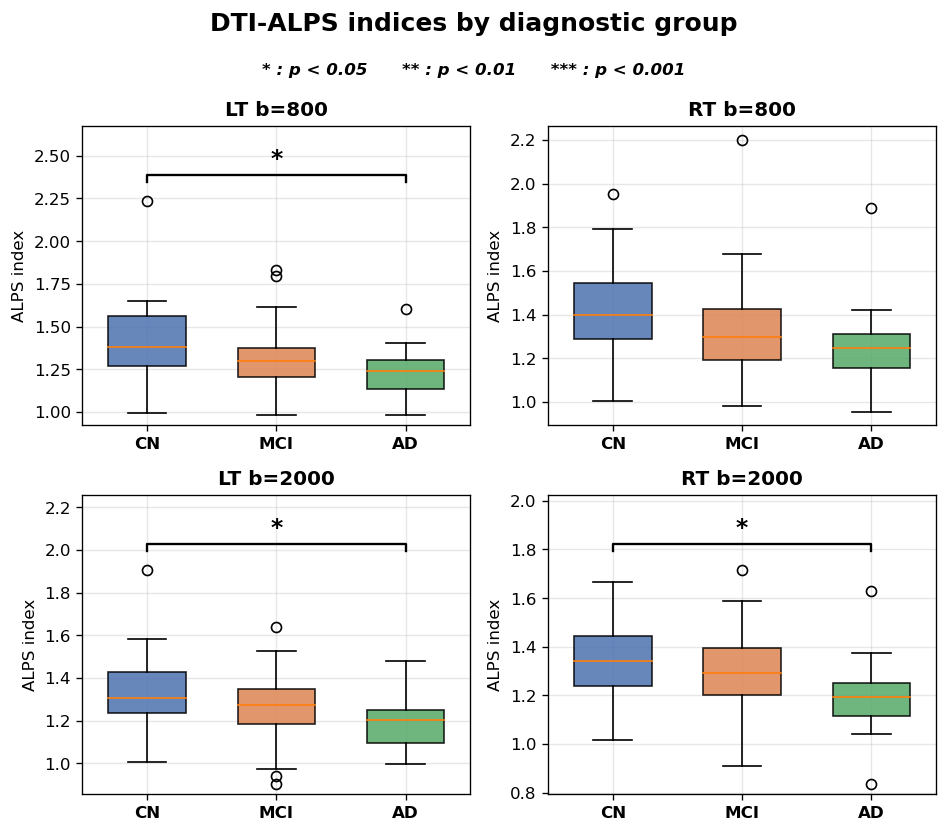

In [78]:
fig, axes = plot_dti_alps_box_with_stats(
    df,
    group_col='Group',              # 네 데이터에 맞게
    group_order=[0,1,2],            # 0=CN, 1=MCI, 2=AD 라고 가정
    group_labels={0:'CN',1:'MCI',2:'AD'},
    alps_cols=alps_cols,
    stats_pairs=stats_pairs,
    figsize=(8, 7),
    savepath=os.path.join(base, "Fig2-0_3GroupComp_DTI_ALPS.tiff")
)

In [110]:
math_titles = {
    # Insula HFC / Hippocampus Volume
    "Insula HFC / Hippocampus Volume":
        r"$\mathit{\mathbf{R}}_{\mathit{\mathbf{Ins/Hippo}}}:\;\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Insula}}}/\mathit{\mathbf{V}}_{\mathit{\mathbf{Hippo}}}$",

    # Hippocampus HFC / Hippocampus Volume
    "Hippocampus HFC / Hippocampus Volume":
        r"$\mathit{\mathbf{R}}_{\mathit{\mathbf{Hippo}}}:\;\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Hippo}}}/\mathit{\mathbf{V}}_{\mathit{\mathbf{Hippo}}}$",

    # Insula HFC / Insula Volume
    "Insula HFC / Insula Volume":
        r"$\mathit{\mathbf{R}}_{\mathit{\mathbf{Insula}}}:\;\mathit{\mathbf{HFC}}_{\mathit{\mathbf{Insula}}}/\mathit{\mathbf{V}}_{\mathit{\mathbf{Insula}}}$",
}

ratio_cols = {
    "R_InsHippo (LT)":  "R_LT_insulaHFC-HippoVol",
    "R_InsHippo (RT)":  "R_RT_insulaHFC-HippoVol",
    "R_Hippo (LT)":     "R_LT_HippoHFC-HippoVol",
    "R_Hippo (RT)":     "R_RT_HippoHFC-HippoVol",
    "R_Insula (LT)":    "R_LT_InsulaHFC-InsulaVol",
    "R_Insula (RT)":    "R_RT_InsulaHFC-InsulaVol",
}

# --- 2) Table의 pairwise p값 정리 --- #
ratio_stats_pairs = {
    "R_LT_insulaHFC-HippoVol": {  # R_InsHippo LT
        (1, 3): 0.0001,
        (2, 3): 0.0024,
    },
    "R_RT_insulaHFC-HippoVol": {  # R_InsHippo RT
        (1, 3): 0.0001,
        (2, 3): 0.0014,
    },
    "R_LT_HippoHFC-HippoVol": {   # R_Hippo LT
        (1, 3): 0.0011,
        (2, 3): 0.0406,
    },
    "R_RT_HippoHFC-HippoVol": {   # R_Hippo RT
        (1, 3): 0.0005,
        (2, 3): 0.0243,
    },
    "R_LT_InsulaHFC-InsulaVol": { # R_Insula LT
        (1, 3): 0.0001,
        (2, 3): 0.0042,
    },
    "R_RT_InsulaHFC-InsulaVol": { # R_Insula RT
        (1, 3): 0.0001,
        (2, 3): 0.0013,
    },
}



def annotate_sig(ax, x1, x2, y_bottom, p, step):
    """
    x1, x2 : 두 그룹의 x좌표
    y_bottom : 브래킷의 아랫선 y좌표 (이미 outlier 위로 결정된 값)
    step : 레벨 간 높이 간격
    브래킷 모양: 각 끝이 위로 꺾인 'ㄷ'자.
    """
    star = p_to_star(p)
    if not star:
        return

    # --- 여기 숫자들만 조정 --- #
    # 브래킷 높이: 조금 낮게 (0.4 → 0.3)
    h_vert = 0.3 * step
    y_top = y_bottom + h_vert

    # ㄷ 모양 브래킷
    ax.plot([x1, x1, x2, x2],
            [y_bottom, y_top, y_top, y_bottom],
            color='k', linewidth=1.4)

    # 별표는 꺾은선과 더 가깝게 (0.25 → 0.10)
    y_text = y_top + 0.05 * step
    ax.text((x1 + x2) / 2, y_text, star,
            ha='center', va='bottom',
            fontsize=14, fontweight='bold')


def plot_ratio_box_with_stats(
    df,
    group_col='Group',
    group_order=(0, 1, 2),
    group_labels=None,
    ratio_cols=None,
    stats_pairs=None,
    figsize=(10, 10),
    savepath=None,
):
    if group_labels is None:
        group_labels = {g: str(g) for g in group_order}
    if ratio_cols is None or stats_pairs is None:
        raise ValueError("ratio_cols와 stats_pairs를 지정해야 합니다.")

    n_panels = len(ratio_cols)
    n_cols = 2
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=120)
    axes = np.array(axes).reshape(-1)  # flatten

    # 군 색 (CN, MCI, AD)
    group_colors = {
        group_order[0]: '#4C72B0',  # CN
        group_order[1]: '#DD8452',  # MCI
        group_order[2]: '#55A868',  # AD
    }

    for ax, (title, col) in zip(axes, ratio_cols.items()):
        if col not in df.columns:
            ax.text(0.5, 0.5, f"{col} not found",
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue

        # --- 그룹별 데이터 --- #
        data = []
        positions = []
        colors_for_boxes = []
        for i, g in enumerate(group_order, start=1):
            vals = pd.to_numeric(df.loc[df[group_col] == g, col],
                                 errors='coerce').dropna()
            data.append(vals.values)
            positions.append(i)
            colors_for_boxes.append(group_colors.get(g, '#AAAAAA'))

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=0.6,
            patch_artist=True,
        )
        for patch, col_box in zip(bp['boxes'], colors_for_boxes):
            patch.set_facecolor(col_box)
            patch.set_alpha(0.85)

        ax.set_xticks(positions)
        ax.set_xticklabels([group_labels[g] for g in group_order])
        for lab in ax.get_xticklabels():
            lab.set_fontweight('bold')
            lab.set_fontsize(10)

        # ax.set_ylabel('Ratio index')
        # ax.set_title(title, fontweight='bold')
        # ax.grid(True, alpha=0.3)
        ax.set_ylabel('Ratio index')

        # --- 수식 기반 제목 구성 --- #
        # ratio_cols의 key 예: "R_InsHippo (LT)", "R_Hippo (RT)" ...
        side = "LT" if "(LT" in title else "RT"
        
        if "R_InsHippo" in title:
            base_name = "Insula HFC / Hippocampus Volume"
        elif "R_Hippo" in title:
            base_name = "Hippocampus HFC / Hippocampus Volume"
        elif "R_Insula" in title:
            base_name = "Insula HFC / Insula Volume"
        else:
            base_name = None
        
        if base_name in math_titles:
            # 수식 + side 표시
            disp_title = f"{math_titles[base_name]} ({side})"
        else:
            # fallback: 원래 문자열
            disp_title = title
        
        ax.set_title(disp_title, fontweight='bold')
        
        ax.grid(True, alpha=0.3)

        # --- 유의한 쌍 브래킷 + 별표 --- #
        pair_dict = stats_pairs.get(col, {})
        sig_pairs = [(pair, p) for pair, p in pair_dict.items() if p < 0.05]

        if sig_pairs and any(len(v) > 0 for v in data):
            all_vals = np.concatenate([v for v in data if len(v) > 0])
            y_data_max = np.max(all_vals)

            ymin, ymax = ax.get_ylim()
            orig_yrange = ymax - ymin if ymax > ymin else 1.0

            # ① 안쪽쌍 → 바깥쌍 순으로 정렬 (거리 기준)
            # 예: (2,3) 먼저, (1,3) 나중
            sig_pairs = sorted(
                sig_pairs,
                key=lambda kv: abs(kv[0][0] - kv[0][1])   # (g1,g2) 거리
            )

            n_pairs = len(sig_pairs)
            # ② outlier 위 여유 + 층 간 간격 넉넉하게
            margin = 0.12 * orig_yrange   # 데이터 위 기본 여유
            step   = 0.18 * orig_yrange   # 층 간 간격 (브래킷+별표 한 세트보다 큼)
            start_y = y_data_max + margin

            new_ymax = start_y + (n_pairs + 1) * step
            ax.set_ylim(ymin, new_ymax)

            # Table의 (1,2,3) → 실제 group 코드 매핑
            map13 = {1: group_order[0], 2: group_order[1], 3: group_order[2]}

            for i_step, ((g1_t, g2_t), p) in enumerate(sig_pairs):
                gg1 = map13[g1_t]
                gg2 = map13[g2_t]

                x1 = positions[group_order.index(gg1)]
                x2 = positions[group_order.index(gg2)]

                # 안쪽쌍이 아래(i_step=0), 바깥쌍이 위로 차곡차곡
                y_bottom = start_y + i_step * step
                annotate_sig(ax, x1, x2, y_bottom, p, step)

    # 여분 axes가 있으면 숨기기
    for ax in axes[n_panels:]:
        ax.axis('off')

    fig.suptitle("Ratio indices by diagnostic group",
                 fontsize=15, fontweight='bold', y=0.97)

    fig.text(
        0.5, 0.915,
        "* : p < 0.05      ** : p < 0.01      *** : p < 0.001",
        ha='center', va='center',
        fontsize=10, fontweight='bold', fontstyle='italic'
    )

    fig.tight_layout(rect=[0, 0, 1, 0.935])

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print("Saved to:", savepath)

    return fig, axes

Saved to: D:\JHAhn\files\Fig2-1_3GroupComp_Ratioes.tiff


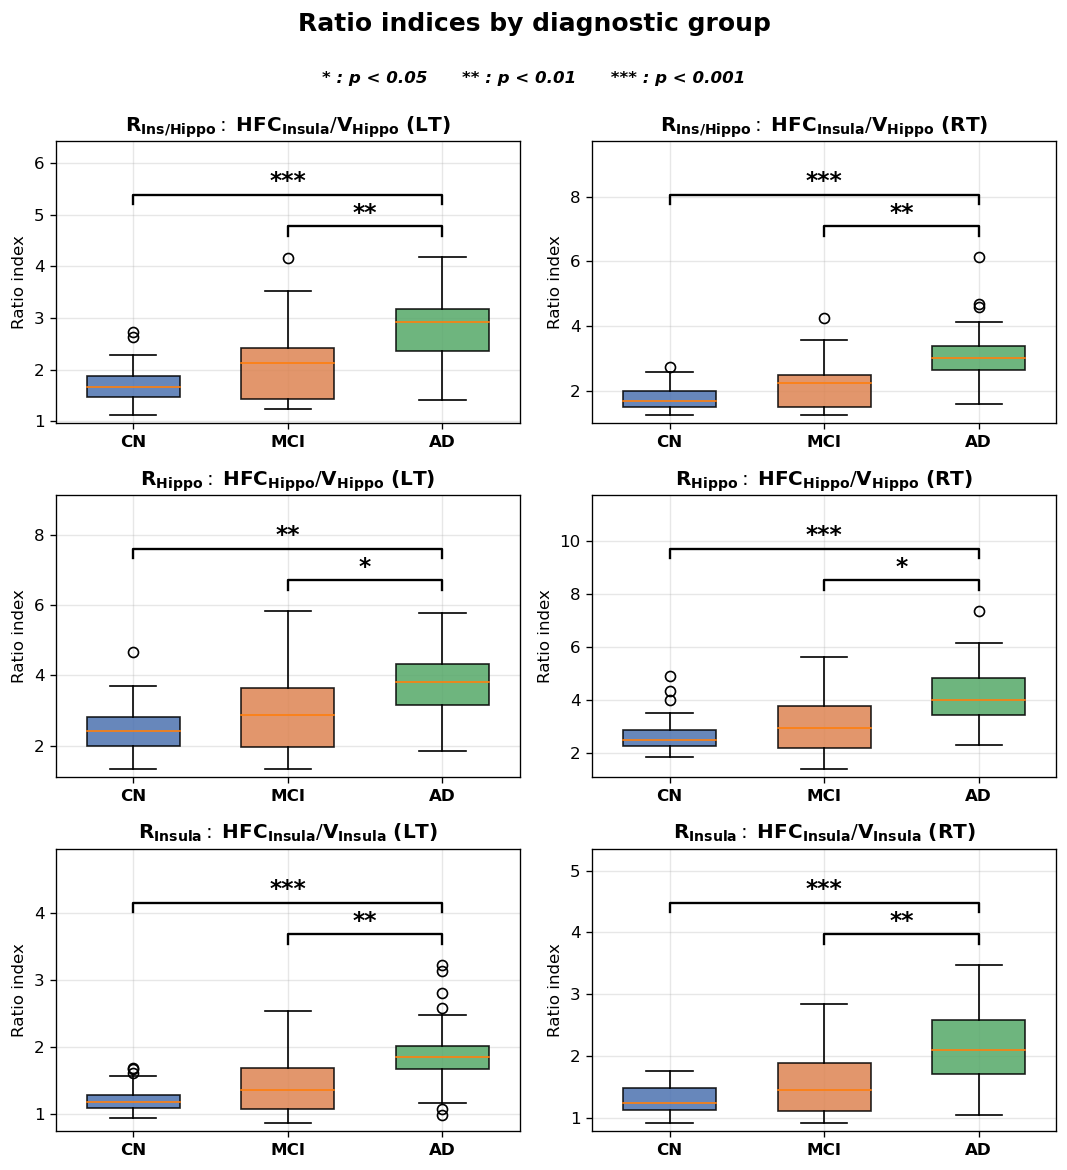

In [111]:
fig_ratio, axes_ratio = plot_ratio_box_with_stats(
    df=df,
    group_col='Group',                 # DTI-ALPS 때와 동일
    group_order=[0, 1, 2],             # 예: 0=CN, 1=MCI, 2=AD
    group_labels={0: 'CN', 1: 'MCI', 2: 'AD'},
    ratio_cols=ratio_cols,
    stats_pairs=ratio_stats_pairs,
    figsize=(9, 10),
    savepath=os.path.join(base, "Fig2-1_3GroupComp_Ratioes.tiff"),
)

In [114]:
hfc_cols = {
    "Hippocampus (LT)": "HFC_LT_Hippocampus",
    "Hippocampus (RT)": "HFC_RT_Hippocampus",
    "Insula (LT)":      "HFC_LT_Insula",
    "Insula (RT)":      "HFC_RT_Insula",
}

# --- HFC pairwise p-values (significant pairs only) --- #
hfc_stats_pairs = {
    # Hippocampus: 유의한 pair 없음 → 빈 dict
    "HFC_LT_Hippocampus": {},
    "HFC_RT_Hippocampus": {},

    # Insula LT
    "HFC_LT_Insula": {
        (1, 3): 0.0010,
        (2, 3): 0.0044,
    },
    # Insula RT
    "HFC_RT_Insula": {
        (1, 3): 0.0004,
        (2, 3): 0.0002,
    },
}

def plot_hfc_box_with_stats(
    df,
    group_col='Group',
    group_order=(0, 1, 2),
    group_labels=None,
    hfc_cols=None,
    stats_pairs=None,
    figsize=(9, 8),
    savepath=None,
):
    if group_labels is None:
        group_labels = {g: str(g) for g in group_order}
    if hfc_cols is None or stats_pairs is None:
        raise ValueError("hfc_cols와 stats_pairs를 지정해야 합니다.")

    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=120)
    axes = axes.ravel()

    # 군 색 (CN, MCI, AD)
    group_colors = {
        group_order[0]: '#4C72B0',  # CN
        group_order[1]: '#DD8452',  # MCI
        group_order[2]: '#55A868',  # AD
    }

    for ax, (title, col) in zip(axes, hfc_cols.items()):
        if col not in df.columns:
            ax.text(0.5, 0.5, f"{col} not found",
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue

        # --- 그룹별 데이터 --- #
        data = []
        positions = []
        colors_for_boxes = []
        for i, g in enumerate(group_order, start=1):
            vals = pd.to_numeric(df.loc[df[group_col] == g, col],
                                 errors='coerce').dropna()
            data.append(vals.values)
            positions.append(i)
            colors_for_boxes.append(group_colors.get(g, '#AAAAAA'))

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=0.6,
            patch_artist=True,
        )
        for patch, col_box in zip(bp['boxes'], colors_for_boxes):
            patch.set_facecolor(col_box)
            patch.set_alpha(0.85)

        ax.set_xticks(positions)
        ax.set_xticklabels([group_labels[g] for g in group_order])
        for lab in ax.get_xticklabels():
            lab.set_fontweight('bold')
            lab.set_fontsize(10)

        ax.set_ylabel('HFC (S/m)')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # --- 유의한 쌍 브래킷 + 별표 --- #
        pair_dict = stats_pairs.get(col, {})
        sig_pairs = [(pair, p) for pair, p in pair_dict.items() if p < 0.05]

        if sig_pairs and any(len(v) > 0 for v in data):
            all_vals = np.concatenate([v for v in data if len(v) > 0])
            y_data_max = np.max(all_vals)

            ymin, ymax = ax.get_ylim()
            orig_yrange = ymax - ymin if ymax > ymin else 1.0

            # 안쪽쌍 → 바깥쌍 순으로 정렬
            sig_pairs = sorted(
                sig_pairs,
                key=lambda kv: abs(kv[0][0] - kv[0][1])
            )

            n_pairs = len(sig_pairs)
            margin = 0.12 * orig_yrange
            step   = 0.18 * orig_yrange
            start_y = y_data_max + margin

            new_ymax = start_y + (n_pairs + 1) * step
            ax.set_ylim(ymin, new_ymax)

            # Table의 (1,2,3) → 실제 group 코드 매핑
            map13 = {1: group_order[0], 2: group_order[1], 3: group_order[2]}

            for i_step, ((g1_t, g2_t), p) in enumerate(sig_pairs):
                gg1 = map13[g1_t]
                gg2 = map13[g2_t]

                x1 = positions[group_order.index(gg1)]
                x2 = positions[group_order.index(gg2)]

                y_bottom = start_y + i_step * step
                annotate_sig(ax, x1, x2, y_bottom, p, step)

    fig.suptitle("High-frequency conductivity (HFC) by diagnostic group",
                 fontsize=15, fontweight='bold', y=0.985)

    fig.text(
        0.5, 0.915,
        "* : p < 0.05      ** : p < 0.01      *** : p < 0.001",
        ha='center', va='center',
        fontsize=10, fontweight='bold', fontstyle='italic'
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print("Saved to:", savepath)

    return fig, axes

Saved to: D:\JHAhn\files\Fig2-2_3GroupComp_HFC.tiff


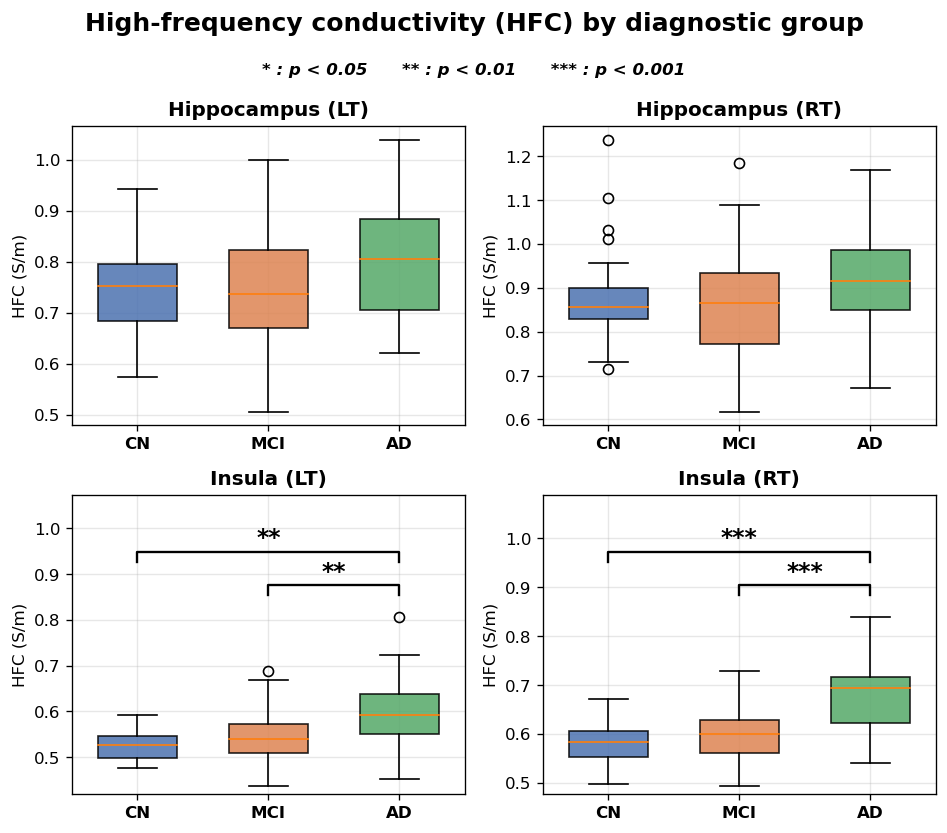

In [115]:
fig_hfc, axes_hfc = plot_hfc_box_with_stats(
    df,
    group_col='Group',                      # DTI/Ratio 때와 동일
    group_order=[0, 1, 2],                  # 0=CN, 1=MCI, 2=AD (예시)
    group_labels={0: 'CN', 1: 'MCI', 2: 'AD'},
    hfc_cols=hfc_cols,
    stats_pairs=hfc_stats_pairs,
    figsize=(8, 7),
    savepath=os.path.join(base, "Fig2-2_3GroupComp_HFC.tiff"),
)

In [116]:
vol_cols = {
    "Hippocampus (LT)": "LT_Hippocampus",
    "Hippocampus (RT)": "RT_Hippocampus",
    "Insula (LT)":      "LT_Insula_CTX",
    "Insula (RT)":      "RT_Insula_CTX",
}

vol_stats_pairs = {
    "LT_Hippocampus": {          # Hippocampus LT
        (1, 3): 0.0001,
    },
    "RT_Hippocampus": {          # Hippocampus RT
        (1, 3): 0.0001,
        (2, 3): 0.0325,
    },
    "LT_Insula_CTX": {           # Insula LT
        (1, 3): 0.0001,
        (2, 3): 0.0378,
    },
    "RT_Insula_CTX": {           # Insula RT
        (1, 3): 0.0001,
        (2, 3): 0.0312,
    },
}


def plot_tissue_volume_box_with_stats(
    df,
    group_col='Group',
    group_order=(0, 1, 2),
    group_labels=None,
    vol_cols=None,
    stats_pairs=None,
    figsize=(9, 8),
    savepath=None,
):
    if group_labels is None:
        group_labels = {g: str(g) for g in group_order}
    if vol_cols is None or stats_pairs is None:
        raise ValueError("vol_cols와 stats_pairs를 지정해야 합니다.")

    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=120)
    axes = axes.ravel()

    # 군 색 (CN, MCI, AD)
    group_colors = {
        group_order[0]: '#4C72B0',  # CN
        group_order[1]: '#DD8452',  # MCI
        group_order[2]: '#55A868',  # AD
    }

    for ax, (title, col) in zip(axes, vol_cols.items()):
        if col not in df.columns:
            ax.text(0.5, 0.5, f"{col} not found",
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue

        # --- 그룹별 데이터 --- #
        data = []
        positions = []
        colors_for_boxes = []
        for i, g in enumerate(group_order, start=1):
            vals = pd.to_numeric(df.loc[df[group_col] == g, col],
                                 errors='coerce').dropna()
            data.append(vals.values)
            positions.append(i)
            colors_for_boxes.append(group_colors.get(g, '#AAAAAA'))

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=0.6,
            patch_artist=True,
        )
        for patch, col_box in zip(bp['boxes'], colors_for_boxes):
            patch.set_facecolor(col_box)
            patch.set_alpha(0.85)

        ax.set_xticks(positions)
        ax.set_xticklabels([group_labels[g] for g in group_order])
        for lab in ax.get_xticklabels():
            lab.set_fontweight('bold')
            lab.set_fontsize(10)

        ax.set_ylabel('Tissue volume')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # --- 유의한 쌍 브래킷 + 별표 --- #
        pair_dict = stats_pairs.get(col, {})
        sig_pairs = [(pair, p) for pair, p in pair_dict.items() if p < 0.05]

        if sig_pairs and any(len(v) > 0 for v in data):
            all_vals = np.concatenate([v for v in data if len(v) > 0])
            y_data_max = np.max(all_vals)

            ymin, ymax = ax.get_ylim()
            orig_yrange = ymax - ymin if ymax > ymin else 1.0

            # 안쪽쌍 → 바깥쌍 순으로 정렬
            sig_pairs = sorted(
                sig_pairs,
                key=lambda kv: abs(kv[0][0] - kv[0][1])
            )

            n_pairs = len(sig_pairs)
            margin = 0.12 * orig_yrange
            step   = 0.18 * orig_yrange
            start_y = y_data_max + margin

            new_ymax = start_y + (n_pairs + 1) * step
            ax.set_ylim(ymin, new_ymax)

            # Table의 (1,2,3) → 실제 group 코드 매핑
            map13 = {1: group_order[0], 2: group_order[1], 3: group_order[2]}

            for i_step, ((g1_t, g2_t), p) in enumerate(sig_pairs):
                gg1 = map13[g1_t]
                gg2 = map13[g2_t]

                x1 = positions[group_order.index(gg1)]
                x2 = positions[group_order.index(gg2)]

                y_bottom = start_y + i_step * step
                annotate_sig(ax, x1, x2, y_bottom, p, step)

    fig.suptitle("Tissue volume by diagnostic group",
                 fontsize=15, fontweight='bold', y=0.985)

    fig.text(
        0.5, 0.915,
        "* : p < 0.05      ** : p < 0.01      *** : p < 0.001",
        ha='center', va='center',
        fontsize=10, fontweight='bold', fontstyle='italic'
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print("Saved to:", savepath)

    return fig, axes

Saved to: D:\JHAhn\files\Fig2-3_3GroupComp_TiV.tiff


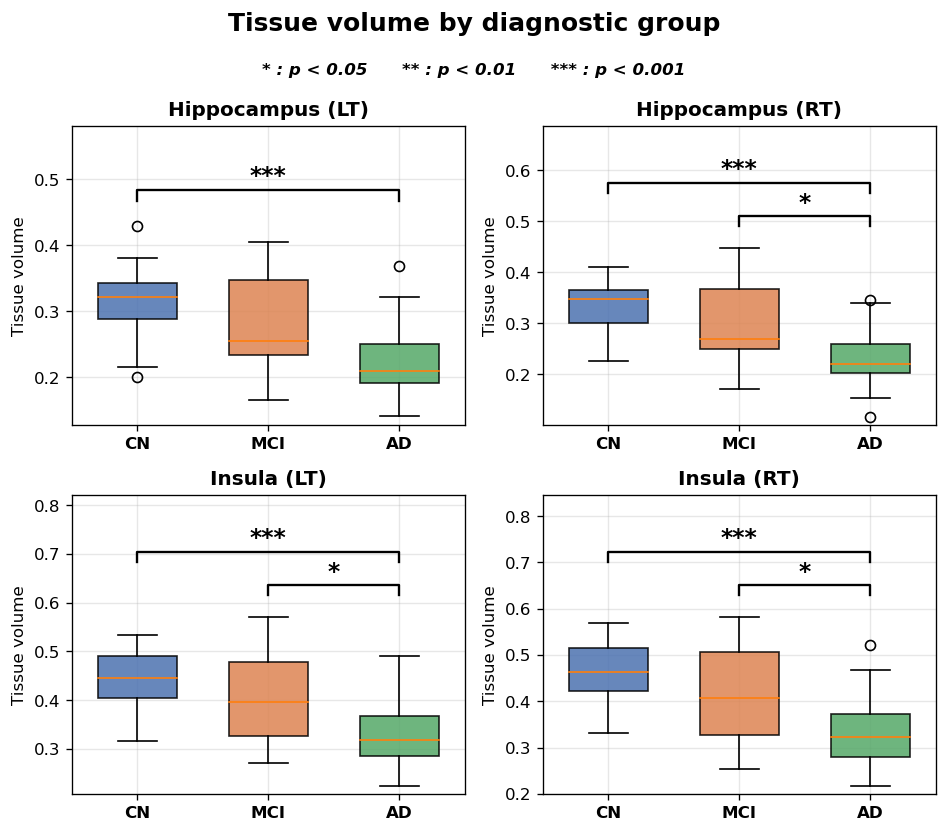

In [117]:
fig_vol, axes_vol = plot_tissue_volume_box_with_stats(
    df,
    group_col='Group',                          # 기존과 동일
    group_order=[0, 1, 2],                      # 0=CN, 1=MCI, 2=AD (예시)
    group_labels={0: 'CN', 1: 'MCI', 2: 'AD'},
    vol_cols=vol_cols,
    stats_pairs=vol_stats_pairs,
    figsize=(8, 7),
    savepath=os.path.join(base, "Fig2-3_3GroupComp_TiV.tiff"),
)